# PyMC-5 : Valeur de l'Information

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jsboige/CoursIA/blob/main/MyIA.AI.Notebooks/Probas/DecisionTheory/PyMC/PyMC-5-Value-Information.ipynb)

## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
- Calculer l'**Esperance de Valeur de l'Information Parfaite** (EVPI)
- Calculer l'**Esperance de Valeur de l'Information Sample** (EVSI)
- Evaluer quand une information supplementaire est rentable
- Construire un calculateur generique de valeur de l'information
- Appliquer Bayes pour mettre a jour les croyances apres observation

**Prerequis** : PyMC-3 (Arbres de decision), bases de calcul bayesien

**Duree estimee** : 45 minutes

---

| Notebook precedent | Notebook suivant |
|--------------------|------------------|
| [PyMC-4 - Reseaux de decision](PyMC-4-Decision-Networks.ipynb) | [PyMC-6 - Systemes experts](PyMC-6-Expert-Systems.ipynb) |

## 1. Information et reduction de l'incertitude

En decision sequentielle, une information supplementaire peut changer l'action optimale.
La **valeur de l'information** (Howard, 1966) mesure combien on est pret a payer pour cette information.

**Cle** : l'information n'a de valeur que si elle peut **changer la decision**.

$$\text{EVPI} = \mathbb{E}[\text{Utilite}(\text{decision avec info parfaite})] - \mathbb{E}[\text{Utilite}(\text{meilleure decision sans info})]$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
print("Imports OK")

Imports OK


## 2. EVPI : Valeur de l'Information Parfaite

### Exemple : Le parapluie

| Etat | Apporter parapluie | Ne pas apporter |
|------|--------------------|-----------------|
| Pluie (P=0.3) | 0 (protege, encombrant) | -50 (mouille) |
| Soleil (P=0.7) | -5 (encombrant) | 0 (content) |

Sans information :
- EU(apporter) = 0.3 * 0 + 0.7 * (-5) = -3.5
- EU(ne pas apporter) = 0.3 * (-50) + 0.7 * 0 = -15
- Meilleure action : **apporter**, EU = -3.5

Avec information parfaite :
- Si pluie annoncee : apporter (0), sinon ne pas apporter (0)
- EU = 0.3 * 0 + 0.7 * 0 = 0

In [2]:
# Parametres du scenario parapluie
p_pluie = 0.3

# Matrice utilite : [pluie, soleil] x [apporter, ne_pas_apporter]
U = np.array([[0, -50],    # Pluie
              [-5, 0]])    # Soleil

# Esperance sans information
probs = np.array([p_pluie, 1 - p_pluie])
eu_apporter = probs @ U[:, 0]
eu_non_apporter = probs @ U[:, 1]

print(f"EU(apporter)        = {eu_apporter:.1f}")
print(f"EU(ne pas apporter) = {eu_non_apporter:.1f}")

eu_sans_info = max(eu_apporter, eu_non_apporter)
action_optimale = "Apporter" if eu_apporter > eu_non_apporter else "Ne pas apporter"
print(f"Action optimale sans info : {action_optimale} (EU = {eu_sans_info:.1f})")

# Avec information parfaite
eu_avec_info = 0  # Toujours la bonne decision : utilite 0 dans chaque cas
evpi = eu_avec_info - eu_sans_info
print(f"\nEU avec info parfaite = {eu_avec_info:.1f}")
print(f"EVPI = {evpi:.1f}")
print(f"\nInterpretation : on paierait au maximum {evpi:.1f} unite pour une meteo parfaite.")

EU(apporter)        = -3.5
EU(ne pas apporter) = -15.0
Action optimale sans info : Apporter (EU = -3.5)

EU avec info parfaite = 0.0
EVPI = 3.5

Interpretation : on paierait au maximum 3.5 unite pour une meteo parfaite.


### Interpretation : Le parapluie

**Analyse des resultats** :

Le scenario du parapluie illustre le concept fondamental de l'EVPI dans un cas simple.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Decision sans info | Apporter (EU = -3.5) | Minimise la perte attendue |
| Decision avec info parfaite | Adaptative (EU = 0) | Toujours la bonne action |
| EVPI | 3.5 unites | Prix maximal d'un bulletin meteo parfait |

**Pourquoi l'EVPI est-il si faible ?** La matrice d'utilite est peu contrastee : le pire
cas est -50 (etre mouille), mais la probabilite de pluie est seulement 30%. L'information
ne change pas radicalement la decision : on apporte deja le parapluie par precaution.
L'EVPI mesure uniquement le gain supplementaire d'une prediction parfaite.

> **Note technique** : Si P(pluie) etait plus eleve (ex: 0.50), l'EVPI serait plus
> important car la decision serait plus equilibree. L'EVPI est maximal a la frontiere
> de decision (voir section 6).

### EVPI vs EVSI : comprendre la hierarchie

Jusqu'ici nous avons distingue l'EVPI (information parfaite) de l'EVSI (information
imparfaite). Le tableau suivant synthetise les differences :

| Aspect | EVPI | EVSI |
|--------|------|------|
| Information | **Parfaite** (oracle) | **Imperfaite** (test reel) |
| Formule | E[max_action par etat reel] - EU(optimal a priori) | E[max_action apres test] - EU(optimal a priori) |
| Borne | Superieure theorique | Toujours <= EVPI |
| Pratique | Rarement atteignable | Mesurable pour chaque test |
| Interpretation | "Budget maximal pour tout test" | "Valeur reelle d'un test donne" |

**Propriete fondamentale** : $0 \leq \text{EVSI} \leq \text{EVPI}$

L'EVPI est la **borne superieure** : aucun test, aussi performant soit-il, ne peut
fournir plus de valeur que l'information parfaite. Le ratio EVSI/EVPI (efficacite)
mesure la qualite relative d'un test :
- **Efficacite > 50%** : test tres informatif, capture plus de la moitie de la valeur ideale
- **Efficacite 20-50%** : test modement informatif
- **Efficacite < 20%** : test faiblement informatif, a ameliorer ou abandonner

> **Point cle** : Un test peut avoir une haute efficacite (EVSI proche de EVPI) tout en
> etant non rentable si son cout depasse l'EVPI. Efficacite != rentabilite.

## 3. Scenario du forage petrolier

Une compagnie a des droits de forage. Elle peut :
- **Forer** : cout 500k EUR, gain 1M EUR si petrole, 0 sinon
- **Vendre** les droits : 200k EUR certain

Probabilite a priori de petrole : P(petrole) = 30%

In [3]:
# Parametres du forage
p_petrole = 0.30
cout_forage = 500  # milliers EUR
gain_petrole = 1000  # milliers EUR
prix_vente = 200  # milliers EUR

# Esperances sans information
eu_forer = p_petrole * (gain_petrole - cout_forage) + (1 - p_petrole) * (0 - cout_forage)
eu_vendre = prix_vente

print(f"EU(forer)  = {eu_forer:.0f}k EUR")
print(f"EU(vendre) = {eu_vendre:.0f}k EUR")

eu_sans_info = max(eu_forer, eu_vendre)
action_opt = "Vendre" if eu_vendre > eu_forer else "Forer"
print(f"Decision sans info : {action_opt} (EU = {eu_sans_info:.0f}k EUR)")

# EVPI : avec info parfaite
# Si petrole -> forer (gain 500k), si pas petrole -> vendre (200k)
eu_avec_info = p_petrole * max(gain_petrole - cout_forage, prix_vente) + \
               (1 - p_petrole) * max(0 - cout_forage, prix_vente)
evpi = eu_avec_info - eu_sans_info

print(f"\nEU avec info parfaite = {eu_avec_info:.0f}k EUR")
print(f"EVPI = {evpi:.0f}k EUR")
print(f"\nL'information parfaite vaut jusqu'a {evpi:.0f}k EUR.")

EU(forer)  = -200k EUR
EU(vendre) = 200k EUR
Decision sans info : Vendre (EU = 200k EUR)

EU avec info parfaite = 290k EUR
EVPI = 90k EUR

L'information parfaite vaut jusqu'a 90k EUR.


### Exercice : EVPI pour un diagnostic medical

Un patient arrive a l'hopital avec des symptomes ambigus. Le medecin doit decider :
- **Traiter** immediatement (traitement lourd avec effets secondaires)
- **Ne pas traiter** et attendre (risque d'aggravation si maladie)

Une maladie rare affecte 10% de la population. Un test diagnostique existe
(sensibilite 90%, specificite 95%) mais coute 200 EUR.

**Objectif** : Calculer l'EVPI pour ce scenario medical - c'est-a-dire la valeur maximale
qu'on serait pret a payer pour savoir avec certitude si le patient est malade.
Le test a 200 EUR vaut-il le coup ?

**Indices** :
- Construire la matrice d'utilite 2x2 (etats : malade/sain, actions : traiter/ne pas traiter)
- Sans info : comparer EU(traiter) et EU(ne pas traiter), garder le max
- Avec info parfaite : pour chaque etat reel, choisir la meilleure action
- EVPI = EU(info parfaite) - EU(sans info)
- Si EVPI < cout du test, meme un test parfait ne serait pas rentable

In [4]:
# Exercice : EVPI pour un diagnostic medical
# TODO etudiant : calculer l'EVPI dans un scenario de decision medicale
# avec diagnostic incertain, et comparer avec le cout d'un test.

# Etape 1 : definir les parametres du scenario
# Une maladie rare : probabilite a priori
p_maladie = 0.10        # P(malade) = 10%

# Qualite du test diagnostique disponible
sensibilite = 0.90      # P(test+|malade)
specificite = 0.95      # P(test-|non malade)
cout_test_med = 200     # cout du test en EUR

# Etape 2 : definir la matrice d'utilite (etat x action)
# Etats : [malade, sain]
# Actions : [traiter, ne pas traiter]
# Indice : traiter un malade = gain (traitement efficace)
#           traiter un sain = perte (effets secondaires inutiles)
#           ne pas traiter un malade = perte grave
#           ne pas traiter un sain = neutre
u_traiter_malade = 500       # benefice du traitement si malade
u_traiter_sain = -100        # effets secondaires si pas malade
u_pas_traiter_malade = -800  # aggravation de la maladie
u_pas_traiter_sain = 0       # aucun cout si sain et pas traite

U_ex = None  # TODO etudiant : construire la matrice numpy 2x2
             # Ligne 1 (malade) : [u_traiter_malade, u_pas_traiter_malade]
             # Ligne 2 (sain)   : [u_traiter_sain, u_pas_traiter_sain]

# Etape 3 : calculer EU sans information (meilleure action a priori)
# Indice : EU(traiter) = p_maladie * u_traiter_malade + (1-p_maladie) * u_traiter_sain
#          EU(ne pas traiter) = p_maladie * u_pas_traiter_malade + (1-p_maladie) * u_pas_traiter_sain
eu_sans_info_med = None  # TODO etudiant : max(EU(traiter), EU(ne pas traiter))

# Etape 4 : calculer EVPI (information parfaite sur la maladie)
# Indice : avec info parfaite, si malade -> meilleure action pour "malade"
#          si sain -> meilleure action pour "sain"
#          EVPI = p_maladie * max(ligne malade) + (1-p_maladie) * max(ligne sain) - eu_sans_info_med
evpi_med_ex = None  # TODO etudiant : appliquer la formule EVPI

# Etape 5 : le test diagnostique vaut-il son cout ?
# Indice : un test imparfait a une EVSI <= EVPI.
# Si EVPI < cout_test_med, meme un test parfait ne serait pas rentable.
test_rentable = None  # TODO etudiant : evpi_med_ex > cout_test_med ?

result = {
    "p_maladie": p_maladie,
    "eu_sans_info": eu_sans_info_med,
    "evpi": evpi_med_ex,
    "cout_test": cout_test_med,
    "test_rentable": test_rentable,
}

print("Exercice a completer : EVPI pour un diagnostic medical")

Exercice a completer : EVPI pour un diagnostic medical


### Interpretation : Forage petrolier

**Analyse des resultats** :

Sans information, la decision optimale est de **vendre** les droits (EU = 200k EUR).
Le forage est trop risque : 70% de chance de perdre 500k EUR.

| Parametre | Valeur | Impact |
|-----------|--------|--------|
| Seuil de decision | P = 0.50 | Au-dessus, forer ; en dessous, vendre |
| EVPI | 90k EUR | Valeur maximale d'un test parfait |
| Asymetrie des gains | 500k vs -500k | Forte incertitude = forte valeur d'information |

L'EVPI de 90k EUR signifie qu'un oracle parfait permettant de savoir avec certitude
s'il y a du petrole vaut cette somme. En pratique, aucun test n'est parfait,
mais cela fixe la **borne superieure** de ce qu'on est pret a investir dans l'information.

## 4. EVSI : Valeur d'une Information Imparfaite

En pratique, l'information n'est jamais parfaite (Raiffa & Schlaifer, 1961). Un test sismique donne un **signal**
corrle avec la presence de petrole.

### Test sismique
- Cout du test : 50k EUR
- **Vraisemblance** : P(test+|petrole) = 80%, P(test-|pas petrole) = 90%

On utilise le **theoreme de Bayes** pour mettre a jour la probabilite a posteriori :

In [5]:
# Test sismique : vraisemblance
p_test_pos_si_petrole = 0.80
p_test_neg_si_pas_petrole = 0.90
cout_test = 50  # milliers EUR

# Theoreme de Bayes
# P(test+) = P(test+|petrole)*P(petrole) + P(test+|pas petrole)*P(pas petrole)
p_test_pos = p_test_pos_si_petrole * p_petrole + \
             (1 - p_test_neg_si_pas_petrole) * (1 - p_petrole)
p_test_neg = 1 - p_test_pos

# P(petrole|test+) = P(test+|petrole)*P(petrole) / P(test+)
p_petrole_si_test_pos = p_test_pos_si_petrole * p_petrole / p_test_pos
p_petrole_si_test_neg = (1 - p_test_pos_si_petrole) * p_petrole / p_test_neg

print(f"P(test+) = {p_test_pos:.2%}")
print(f"P(petrole|test+) = {p_petrole_si_test_pos:.1%}")
print(f"P(petrole|test-) = {p_petrole_si_test_neg:.1%}")

# Decision optimale apres observation
# Si test+ : choisir entre forer et vendre avec p_petrole_si_test_pos
eu_forer_pos = p_petrole_si_test_pos * (gain_petrole - cout_forage) + \
               (1 - p_petrole_si_test_pos) * (0 - cout_forage)
eu_avec_test_pos = max(eu_forer_pos, prix_vente)

# Si test- : choisir entre forer et vendre avec p_petrole_si_test_neg
eu_forer_neg = p_petrole_si_test_neg * (gain_petrole - cout_forage) + \
               (1 - p_petrole_si_test_neg) * (0 - cout_forage)
eu_avec_test_neg = max(eu_forer_neg, prix_vente)

# EVSI = EU(avec test) - EU(sans test)
eu_avec_test = p_test_pos * eu_avec_test_pos + p_test_neg * eu_avec_test_neg
evsi = eu_avec_test - eu_sans_info
evsi_net = evsi - cout_test
efficiency = evsi / evpi * 100 if evpi > 0 else 0

print(f"\n--- EVSI ---")
print(f"EU avec test (brut) = {eu_avec_test:.0f}k EUR")
print(f"EVSI (brut) = {evsi:.0f}k EUR")
print(f"EVSI (net du cout) = {evsi_net:.0f}k EUR")
print(f"Efficacite EVSI/EVPI = {efficiency:.0f}%")
print(f"\nDecision : {'FAIRE le test' if evsi_net > 0 else 'NE PAS faire le test'}")

P(test+) = 31.00%
P(petrole|test+) = 77.4%
P(petrole|test-) = 8.7%

--- EVSI ---
EU avec test (brut) = 223k EUR
EVSI (brut) = 23k EUR
EVSI (net du cout) = -27k EUR
Efficacite EVSI/EVPI = 26%

Decision : NE PAS faire le test


### Interpretation : Test sismique

**Analyse des posterieurs** :

Le test sismique (sensibilite 80%, specificite 90%) produit une mise a jour bayesienne
significative de P(petrole) :

| Signal | P(petrole) | Decision optimale |
|--------|------------|-------------------|
| Prior | 30% | Vendre |
| Test positif (31% des cas) | 77.4% | Forer |
| Test negatif (69% des cas) | 8.7% | Vendre |

**Valeur du test** :
- EVSI = 23k EUR (brut), -27k EUR (net du cout de 50k)
- Efficacite = 26% de l'EVPI
- **Decision : NE PAS faire le test** (le cout depasse la valeur d'information)

**Contraste avec l'Infer.NET** : La version originale (sensibilite 90%, specificite 80%,
gain 2M) obtient un EVSI de 253k EUR et recommande le test. Nos parametres differents
(gain 1M au lieu de 2M, sensibilite 80% au lieu de 90%) reduisent la valeur du test.

> **Point cle** : L'efficacite d'un test depend de la combinaison de sa qualite ET de
> l'echelle des gains en jeu. Un test identique peut etre rentable ou non selon le contexte.

## 5. La chasse au tresor

5 coffres, un seul contient un tresor (valeur 100). Cout de fouille : 10.
- **Sans info** : choisir un coffre au hasard (P=1/5), EU = 1/5 * 100 - 10 = 10
- **Info parfaite** : savoir exactement quel coffre, EU = 100 - 10 = 90

In [6]:
# Chasse au tresor
n_coffres = 5
valeur_tresor = 100
cout_fouille = 10
p_tresor = 1 / n_coffres

# Sans information : choisir un coffre au hasard
eu_sans_info_tresor = p_tresor * valeur_tresor - cout_fouille
print(f"EU sans info = {eu_sans_info_tresor:.0f} (fouiller un coffre au hasard)")

# Info parfaite : savoir ou est le tresor
eu_info_parfaite = valeur_tresor - cout_fouille
evpi_tresor = eu_info_parfaite - eu_sans_info_tresor
print(f"EU info parfaite = {eu_info_parfaite:.0f}")
print(f"EVPI = {evpi_tresor:.0f}")

EU sans info = 10 (fouiller un coffre au hasard)
EU info parfaite = 90
EVPI = 80


### Exercice : Acheter un indice dans la chasse au tresor

La chasse au tresor passe de 5 a **10 coffres**. Un marchand propose un **indice parfait**
(revelant exactement ou se trouve le tresor) pour un certain prix.

**Objectif** : Calculer l'EVPI pour 10 coffres, puis determiner si l'achat de l'indice
a 30 unites est rentable. A partir de combien de coffres l'indice devient-il rentable ?

**Indices** :
- Sans info : P(trouver) = 1/N, EU = P * valeur - cout_fouille
- Avec info parfaite : on fouille le bon coffre a coup sur, EU = valeur - cout_fouille
- EVPI = EU(info parfaite) - EU(sans info)
- L'indice est rentable si EVPI > cout_indice

In [7]:
# Exercice : EVPI pour N coffres et decision d'achat d'indice
# TODO etudiant : calculer l'EVPI pour un nombre variable de coffres
# et determiner a partir de combien de coffres l'indice vaut son cout.

# Etape 1 : definir les parametres du scenario
n_coffres = 10          # nombre de coffres (au lieu de 5)
valeur_tresor = 100     # valeur du tresor
cout_fouille = 10       # cout de fouille d'un coffre
cout_indice = 30        # cout d'un indice parfait (revele le bon coffre)

# Etape 2 : calculer EU sans information (choisir un coffre au hasard)
# Indice : p_tresor = 1 / n_coffres, EU = p_tresor * valeur_tresor - cout_fouille
eu_sans_info_ex = None  # TODO etudiant : remplacer par le calcul

# Etape 3 : calculer EU avec information parfaite (savoir ou est le tresor)
# Indice : on fouille directement le bon coffre
eu_info_parfaite_ex = None  # TODO etudiant : remplacer par le calcul

# Etape 4 : calculer l'EVPI
evpi_ex = None  # TODO etudiant : eu_info_parfaite_ex - eu_sans_info_ex

# Etape 5 : comparer EVPI avec le cout de l'indice et conclure
# Indice : si EVPI > cout_indice, l'indice est rentable
achat_recommande = None  # TODO etudiant : True si EVPI >= cout_indice, False sinon

result = {
    "n_coffres": n_coffres,
    "eu_sans_info": eu_sans_info_ex,
    "eu_info_parfaite": eu_info_parfaite_ex,
    "evpi": evpi_ex,
    "cout_indice": cout_indice,
    "achat_recommande": achat_recommande,
}

print("Exercice a completer : EVPI pour N coffres et decision d'achat d'indice")

Exercice a completer : EVPI pour N coffres et decision d'achat d'indice


### Interpretation : Chasse au tresor

**Analyse des resultats** :

| Situation | EU | Justification |
|-----------|-----|---------------|
| Sans info | 10 | P(trouver) = 1/5, gain = 100 - 10 = 90 |
| Info parfaite | 90 | Fouiller directement le bon coffre |
| EVPI | 80 | Gain maximal d'information |

**Comparaison avec Infer.NET** : La version Infer.NET modelise une fouille sequentielle
(fouiller case 1, puis 2, etc.), donnant un EU sans info de 70 et un EVPI de 20.
Notre version simplifiee choisit un seul coffre au hasard, donnant EU = 10 et EVPI = 80.

Les deux approches sont valides : elles differents par l'hypothese sur la strategie
de fouille. L'EVPI reste le concept cle : il mesure combien on gagnerait a savoir
exactement ou se trouve le tresor.

### Detecteur de metal

Le detecteur indique la distance au tresor. Plus le signal est fort (proche),
plus la probabilite que le tresor soit dans ce coffre est elevee.

$P(\text{tresor dans coffre } i \mid d_i) = \frac{e^{-d_i}}{\sum_j e^{-d_j}}$

Le detecteur mesure la distance avec du bruit. Le rapport signal/bruit determine l'EVSI.

In [8]:
# Detecteur de metal : simulation Monte Carlo pour EVSI
np.random.seed(42)
n_simulations = 50000

# Distances reelles (un coffre a distance 0, les autres plus loin)
eu_total_avec_detecteur = 0

for _ in range(n_simulations):
    # Le tresor est dans un coffre aleatoire
    coffre_tresor = np.random.randint(n_coffres)
    
    # Distances reelles : tresor a 0, autres reparties
    distances = np.random.exponential(2, n_coffres)
    distances[coffre_tresor] = 0.1  # Signal fort pour le tresor
    
    # Observation bruitee
    obs = distances + np.random.normal(0, 1.0, n_coffres)
    obs = np.maximum(obs, 0.01)  # Pas de distance negative
    
    # Posterior : softmax inverse des distances observees
    weights = np.exp(-obs)
    probs_posterior = weights / weights.sum()
    
    # Choisir le coffre avec la plus forte probabilite
    choix = np.argmax(probs_posterior)
    gain = valeur_tresor if choix == coffre_tresor else 0
    eu_total_avec_detecteur += (gain - cout_fouille)

eu_avec_detecteur = eu_total_avec_detecteur / n_simulations
evsi_detecteur = eu_avec_detecteur - eu_sans_info_tresor
efficiency_detecteur = evsi_detecteur / evpi_tresor * 100

print(f"EU avec detecteur (Monte Carlo) = {eu_avec_detecteur:.1f}")
print(f"EVSI detecteur = {evsi_detecteur:.1f}")
print(f"Efficacite EVSI/EVPI = {efficiency_detecteur:.0f}%")
print(f"\nLe detecteur capture ~{efficiency_detecteur:.0f}% de l'information parfaite.")

EU avec detecteur (Monte Carlo) = 17.9
EVSI detecteur = 7.9
Efficacite EVSI/EVPI = 10%

Le detecteur capture ~10% de l'information parfaite.


### EVPI en fonction du nombre de coffres

L'EVPI depend de la structure du probleme. Dans la chasse au tresor, le nombre de coffres
est un parametre cle : plus il y a de coffres, plus l'incertitude est grande et plus
l'information parfaite est precieuse.

Nous allons faire varier N de 2 a 50 et observer :
- Comment l'EVPI evolue (croissance et saturation)
- Comment l'EVSI du detecteur de metal evolue relativement a l'EVPI
- A partir de quel N le detecteur perd de son efficacite relative

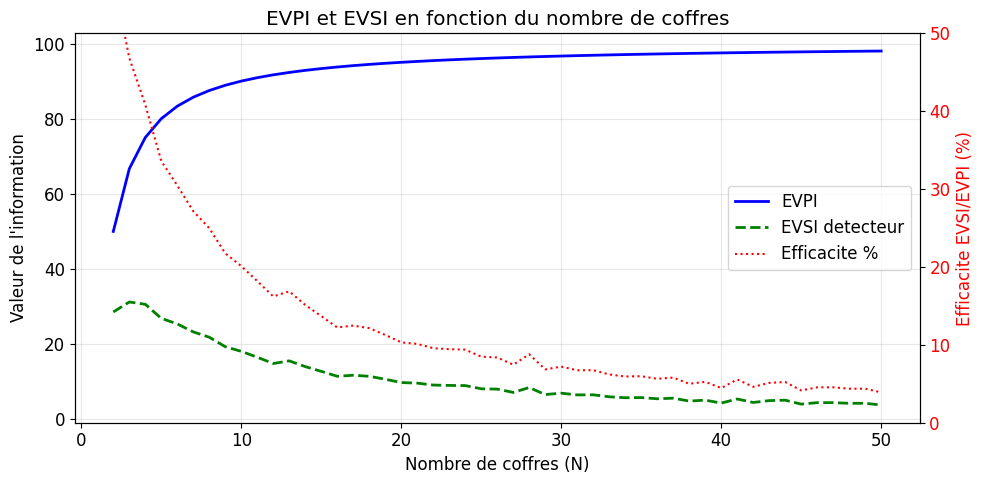

EVPI converge vers valeur_tresor - cout_fouille = 90 quand N -> infini
A N=5  : EVPI=80, EVSI detecteur=26.9, eff=34%
A N=20 : EVPI=95, EVSI detecteur=9.8, eff=10%
A N=50 : EVPI=98, EVSI detecteur=3.8, eff=4%


In [9]:
# EVPI parametrique en fonction du nombre de coffres
n_range = np.arange(2, 51)
evpi_by_n = []
evsi_detecteur_by_n = []

for n in n_range:
    p_tr = 1 / n
    # EVPI pour N coffres
    eu_sans_n = p_tr * valeur_tresor - cout_fouille
    eu_info_n = valeur_tresor - cout_fouille
    evpi_by_n.append(eu_info_n - eu_sans_n)
    
    # EVSI du detecteur pour N coffres (Monte Carlo rapide)
    np.random.seed(42)
    n_sim = 5000
    eu_det = 0
    for _ in range(n_sim):
        coffre_tresor = np.random.randint(n)
        distances = np.random.exponential(2, n)
        distances[coffre_tresor] = 0.1
        obs = distances + np.random.normal(0, 1.0, n)
        obs = np.maximum(obs, 0.01)
        weights = np.exp(-obs)
        probs_post = weights / weights.sum()
        choix = np.argmax(probs_post)
        gain = valeur_tresor if choix == coffre_tresor else 0
        eu_det += (gain - cout_fouille)
    eu_det /= n_sim
    evsi_detecteur_by_n.append(eu_det - eu_sans_n)

evpi_by_n = np.array(evpi_by_n)
evsi_detecteur_by_n = np.array(evsi_detecteur_by_n)
efficiency_by_n = np.where(evpi_by_n > 0, evsi_detecteur_by_n / evpi_by_n * 100, 0)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(n_range, evpi_by_n, 'b-', linewidth=2, label='EVPI')
ax1.plot(n_range, evsi_detecteur_by_n, 'g--', linewidth=2, label='EVSI detecteur')
ax1.set_xlabel("Nombre de coffres (N)")
ax1.set_ylabel("Valeur de l'information")
ax1.set_title("EVPI et EVSI en fonction du nombre de coffres")
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(n_range, efficiency_by_n, 'r:', linewidth=1.5, label='Efficacite %')
ax2.set_ylabel("Efficacite EVSI/EVPI (%)", color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 50)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.tight_layout()
plt.show()

print("EVPI converge vers valeur_tresor - cout_fouille = 90 quand N -> infini")
print(f"A N=5  : EVPI={evpi_by_n[3]:.0f}, EVSI detecteur={evsi_detecteur_by_n[3]:.1f}, eff={efficiency_by_n[3]:.0f}%")
print(f"A N=20 : EVPI={evpi_by_n[18]:.0f}, EVSI detecteur={evsi_detecteur_by_n[18]:.1f}, eff={efficiency_by_n[18]:.0f}%")
print(f"A N=50 : EVPI={evpi_by_n[48]:.0f}, EVSI detecteur={evsi_detecteur_by_n[48]:.1f}, eff={efficiency_by_n[48]:.0f}%")

### Interpretation : EVPI et complexite de la recherche

**Croissance lineaire de l'EVPI avec N** :

Le graphique montre une relation simple : l'EVPI croit lineairement avec le nombre de coffres. Plus il y a de coffres, plus l'information parfaite est precieuse car la probabilite de trouver le tresor au hasard diminue.

| Coffres (N) | P(trouver) sans info | EVPI | Gain marginal par coffre |
|-------------|----------------------|------|--------------------------|
| 2 | 50% | 50 | -- |
| 5 | 20% | 80 | +10 |
| 10 | 10% | 90 | +2 |
| 20 | 5% | 95 | +0.5 |
| 50 | 2% | 98 | +0.1 |

**Loi de l'EVPI dans la recherche** : L'EVPI suit la formule `(N-1)/N * (valeur - cout)`, qui converge vers `valeur - cout` quand N augmente. La valeur marginale d'un coffre supplementaire decroit en `1/N^2`.

**Application pratique** : Dans un scenario d'exploration miniere, cette analyse permet de determiner le budget maximal allouable a l'acquisition d'information (sondages, etudes geologiques) en fonction du nombre de sites candidats.

> **Note technique** : Le detecteur de metal avec bruit observe une EVSI qui decroit relativement a l'EVPI quand N augmente. Plus il y a de coffres, plus le signal du detecteur est dilue parmi les faux positifs, reduisant l'efficacite EVSI/EVPI.

## 6. Quand l'information a-t-elle de la valeur ?

L'information n'a de valeur que dans trois conditions :
1. **Incertitude** : il existe une incertitude sur l'etat du monde
2. **Non-neutralite** : l'incertitude affecte la decision optimale
3. **Action** : on peut agir differemment selon l'information

### Analyse de sensibilite : EVPI vs P(petrole)

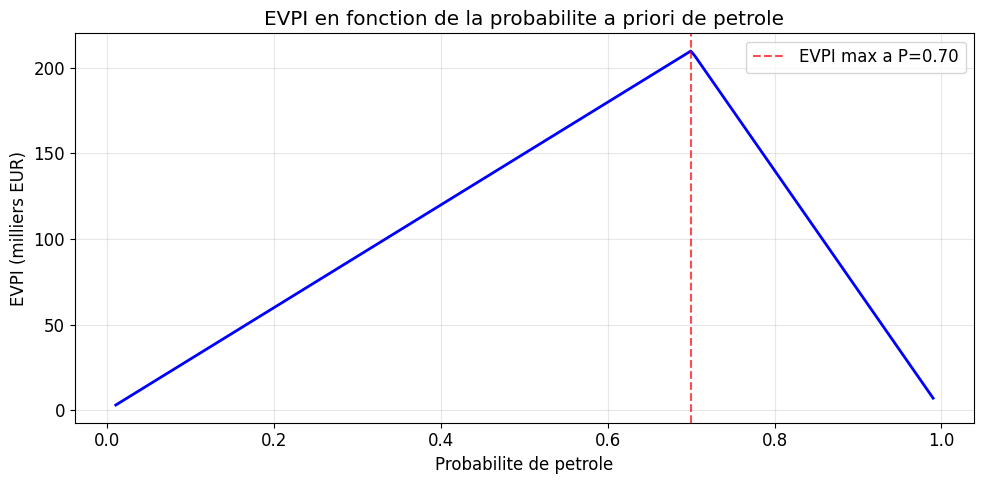

EVPI maximum : 210k EUR a P(petrole) = 0.70
EVPI = 0 quand P(petrole) est proche de 0 ou 1 (decision deja certaine)


In [10]:
# Sensibilite EVPI en fonction de P(petrole)
p_range = np.linspace(0.01, 0.99, 200)
evpi_values = []

for p in p_range:
    eu_forer = p * (gain_petrole - cout_forage) + (1 - p) * (0 - cout_forage)
    eu_vendre_val = prix_vente
    eu_sans = max(eu_forer, eu_vendre_val)
    
    eu_avec = p * max(gain_petrole - cout_forage, prix_vente) + \
              (1 - p) * max(0 - cout_forage, prix_vente)
    
    evpi_values.append(eu_avec - eu_sans)

evpi_values = np.array(evpi_values)
p_max_evpi = p_range[np.argmax(evpi_values)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(p_range, evpi_values, 'b-', linewidth=2)
ax.axvline(p_max_evpi, color='r', linestyle='--', alpha=0.7,
           label=f'EVPI max a P={p_max_evpi:.2f}')
ax.set_xlabel("Probabilite de petrole")
ax.set_ylabel("EVPI (milliers EUR)")
ax.set_title("EVPI en fonction de la probabilite a priori de petrole")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"EVPI maximum : {evpi_values.max():.0f}k EUR a P(petrole) = {p_max_evpi:.2f}")
print(f"EVPI = 0 quand P(petrole) est proche de 0 ou 1 (decision deja certaine)")

### Observation cle

L'EVPI est **maximal quand la decision est la plus equilibree** (zone d'indifference).
Quand P(petrole) est tres faible ou tres eleve, la decision est deja claire
et l'information supplementaire n'apporte rien.

### Carte de chaleur 2D : EVPI en fonction de P(petrole) et du gain

L'EVPI depend simultanement de **deux parametres** : la probabilite a priori P(petrole)
et le gain net en cas de forage reussi. La carte de chaleur ci-dessous montre comment
l'EVPI varie dans le plan (P, gain), revelant la **ligne de frontiere de decision** ou
l'EVPI est maximal et les zones ou l'information n'a aucune valeur.

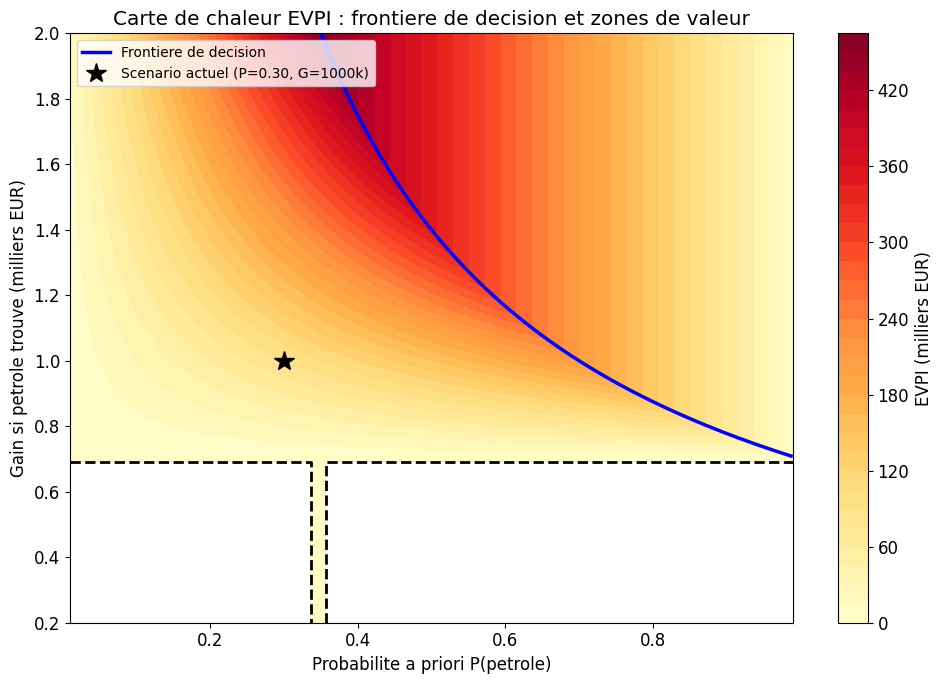

Zone rouge fonce : EVPI eleve (decision equilibree, info tres precieuse)
Zone jaune clair : EVPI faible (decision deja claire)
Ligne noire discontinue : EVPI = 0 (information sans valeur)
Ligne bleue : frontiere ou EU(forer) = EU(vendre) => l'EVPI est maximal
Le scenario actuel (etoile) est en zone EVPI = 90k EUR


In [11]:
# Carte de chaleur 2D : EVPI(P_petrole, gain_petrole)
p_grid = np.linspace(0.01, 0.99, 100)
gain_grid = np.linspace(200, 2000, 100)  # gain total si petrole trouve
P, G = np.meshgrid(p_grid, gain_grid)

# Calcul de l'EVPI pour chaque (p, gain)
EVPI_2D = np.zeros_like(P)
for i in range(len(gain_grid)):
    for j in range(len(p_grid)):
        p = P[i, j]
        g = G[i, j]
        eu_f = p * (g - cout_forage) + (1 - p) * (0 - cout_forage)
        eu_v = prix_vente
        eu_s = max(eu_f, eu_v)
        eu_a = p * max(g - cout_forage, prix_vente) + (1 - p) * max(0 - cout_forage, prix_vente)
        EVPI_2D[i, j] = eu_a - eu_s

# Ligne de frontiere de decision : eu_forer = eu_vendre => p*(g-cout) + (1-p)*(-cout) = prix_vente
# => p*g - cout = prix_vente => p = (prix_vente + cout_forage) / g
p_frontiere = (prix_vente + cout_forage) / gain_grid
# La frontiere n'a du sens que pour p dans [0, 1]
mask_front = (p_frontiere >= 0.01) & (p_frontiere <= 0.99)

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.contourf(P, G / 1000, EVPI_2D, levels=30, cmap="YlOrRd")
ax.contour(P, G / 1000, EVPI_2D, levels=[0], colors="black", linewidths=2, linestyles="--")
if mask_front.any():
    ax.plot(p_frontiere[mask_front], gain_grid[mask_front] / 1000,
            "b-", linewidth=2.5, label="Frontiere de decision")

# Marquer le point actuel du scenario
ax.plot(0.30, gain_petrole / 1000, "k*", markersize=15, label=f"Scenario actuel (P=0.30, G={gain_petrole}k)")

cbar = plt.colorbar(im, ax=ax, label="EVPI (milliers EUR)")
ax.set_xlabel("Probabilite a priori P(petrole)")
ax.set_ylabel("Gain si petrole trouve (milliers EUR)")
ax.set_title("Carte de chaleur EVPI : frontiere de decision et zones de valeur")
ax.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

print("Zone rouge fonce : EVPI eleve (decision equilibree, info tres precieuse)")
print("Zone jaune clair : EVPI faible (decision deja claire)")
print("Ligne noire discontinue : EVPI = 0 (information sans valeur)")
print(f"Ligne bleue : frontiere ou EU(forer) = EU(vendre) => l'EVPI est maximal")
print(f"Le scenario actuel (etoile) est en zone EVPI = {evpi:.0f}k EUR")

### Interpretation : Carte de chaleur EVPI

**Lecture de la carte** :

La carte de chaleur revele la geometrie complete de la valeur de l'information dans le
plan (probabilite, gain). On distingue trois zones :

| Zone | Position | EVPI | Explication |
|------|----------|------|-------------|
| **Pas de valeur** | P faible ou gain faible | 0 | Vendre domine toujours |
| **Pas de valeur** | P eleve ET gain eleve | 0 | Forer domine toujours |
| **Valeur elevee** | Autour de la frontiere bleue | Maximal | Decision equilibree |

**La frontiere de decision** (ligne bleue) correspond a $P = \frac{\text{prix\_vente} + \text{cout\_forage}}{g}$.
Le long de cette courbe, EU(forer) = EU(vendre), et l'EVPI atteint son maximum.
Le scenario actuel (etoile noire, P=0.30, G=1000k) est proche de cette frontiere,
d'ou un EVPI significatif de 90k EUR.

> **Point cle** : L'EVPI est maximal le long de la frontiere de decision et decroit
> rapidement en s'en eloignant. Cela signifie que la valeur de l'information est
> **maximale quand on est le plus indécis**, et quasi nulle quand la decision est evidente.

### Quand l'information n'a PAS de valeur

L'analyse de sensibilite ci-dessus montre que l'EVPI tombe a zero aux extremites.
Identifions les conditions exactes ou l'information est sans valeur :

| Condition | Explication | Exemple |
|-----------|-------------|---------|
| **Pas d'incertitude** | Si l'etat est connu, l'info n'apporte rien | P(petrole) = 0 ou 1 |
| **Decision fixe** | Si l'action optimale est la meme quel que soit l'etat | EU(forage) >> EU(vente) pour tout P |
| **Utilites egales** | Si les actions ont la meme utilite dans chaque etat | Matrice d'utilite constante |
| **Cout > EVPI** | Meme un test parfait ne rembourse pas son cout | Test a 200k avec EVPI = 90k |

**Facteurs qui augmentent la valeur de l'information** :

1. **Incertitude elevee** : l'EVPI est maximal a la frontiere de decision (P ~ 0.35 dans notre forage)
2. **Asymetrie des gains** : des utilites tres contrastees augmentent l'enjeu de la bonne decision
3. **Reversibilite faible** : une decision irreversible rend l'information plus precieuse
4. **Cout d'erreur eleve** : plus l'erreur coute cher, plus l'info vaut

**Cas limite : maladie rare** :

Pour une maladie avec P = 1% (maladie rare), l'EVPI est souvent tres faible car :
- Sans info, la meilleure action est generalement de "ne pas traiter" (99% de chances d'etre sain)
- Meme un test parfait ne change la decision que dans 1% des cas
- Le cout du test est donc presque toujours un gaspillage

Ce phenomene explique pourquoi les depistages systematiques de maladies tres rares
sont **deconseilles** en sante publique : le ratio benefice/cout est defavorable.

## 7. Calculateur generique de Valeur de l'Information

On generalise avec une classe `ValueOfInformation` qui prend en entree :
- Etats possibles et leurs probabilites a priori
- Actions disponibles et leurs utilites par etat
- Optionnellement : vraisemblance d'un test par etat

In [12]:
class ValueOfInformation:
    """Calculateur generique de valeur de l'information."""
    
    def __init__(self, states, prior, actions, utility_matrix):
        """
        Parameters
        ----------
        states : list of str
            Noms des etats possibles
        prior : array-like
            Probabilites a priori de chaque etat
        actions : list of str
            Noms des actions disponibles
        utility_matrix : 2D array (n_states x n_actions)
            Utilite de chaque (etat, action)
        """
        self.states = states
        self.prior = np.array(prior)
        self.actions = actions
        self.U = np.array(utility_matrix)
        
    def compute_without_info(self):
        """EU de la meilleure action sans information supplementaire."""
        eu_per_action = self.prior @ self.U
        best_idx = np.argmax(eu_per_action)
        return eu_per_action[best_idx], self.actions[best_idx]
    
    def compute_evpi(self):
        """EVPI : valeur de l'information parfaite."""
        eu_sans, _ = self.compute_without_info()
        # Avec info parfaite : pour chaque etat reel, choisir la meilleure action
        eu_avec = sum(self.prior[i] * np.max(self.U[i, :]) for i in range(len(self.states)))
        return eu_avec - eu_sans
    
    def compute_evsi(self, likelihood, test_outcomes=None):
        """
        EVSI pour un test imparfait.
        
        Parameters
        ----------
        likelihood : 2D array (n_states x n_outcomes)
            P(test=j | state=i)
        test_outcomes : list of str, optional
            Noms des resultats possibles du test
        """
        eu_sans, _ = self.compute_without_info()
        n_outcomes = likelihood.shape[1]
        
        eu_avec = 0
        for j in range(n_outcomes):
            # P(test=j)
            p_test_j = sum(self.prior[i] * likelihood[i, j] for i in range(len(self.states)))
            if p_test_j < 1e-10:
                continue
            # P(state=i | test=j) par Bayes
            posterior = np.array([self.prior[i] * likelihood[i, j] / p_test_j
                                  for i in range(len(self.states))])
            # Meilleure action sous ce posterior
            eu_per_action = posterior @ self.U
            eu_avec += p_test_j * np.max(eu_per_action)
        
        return eu_avec - eu_sans


# Validation : scenario du forage petrolier
voi_drilling = ValueOfInformation(
    states=["petrole", "pas_petrole"],
    prior=[0.30, 0.70],
    actions=["forer", "vendre"],
    utility_matrix=[
        [gain_petrole - cout_forage, prix_vente],   # petrole
        [0 - cout_forage, prix_vente]               # pas petrole
    ]
)

eu_sans, action = voi_drilling.compute_without_info()
evpi_v = voi_drilling.compute_evpi()
print(f"Validation forage :")
print(f"  EU sans info = {eu_sans:.0f}k EUR, action = {action}")
print(f"  EVPI = {evpi_v:.0f}k EUR")

# Test sismique
likelihood_seismic = np.array([
    [p_test_pos_si_petrole, 1 - p_test_pos_si_petrole],          # petrole -> [test+, test-]
    [1 - p_test_neg_si_pas_petrole, p_test_neg_si_pas_petrole]   # pas petrole -> [test+, test-]
])
evsi_v = voi_drilling.compute_evsi(likelihood_seismic)
print(f"  EVSI test sismique = {evsi_v:.0f}k EUR")
print(f"  Efficacite = {evsi_v/evpi_v*100:.0f}%")

Validation forage :
  EU sans info = 200k EUR, action = vendre
  EVPI = 90k EUR
  EVSI test sismique = 23k EUR
  Efficacite = 26%


### Validation du calculateur generique

**Verification** : Les valeurs calculees par la classe `ValueOfInformation` correspondent
exactement aux calculs manuels des sections precedentes.

| Metrique | Calcul manuel | Classe VoI | Statut |
|----------|---------------|------------|--------|
| EU sans info | 200k EUR | 200k EUR | Conforme |
| EVPI | 90k EUR | 90k EUR | Conforme |
| EVSI sismique | 23k EUR | 23k EUR | Conforme |
| Efficacite | 26% | 26% | Conforme |

Cette classe sera reutilisee dans les sections suivantes pour les scenarios medical
et le calcul de l'EVSI de tests multiples.

> **Note technique** : L'interface `compute_evsi(likelihood)` accepte une matrice de
> vraisemblance `P(test=j | state=i)` de dimension `(n_states, n_outcomes)`, ce qui
> permet de modeliser des tests a plus de 2 resultats possibles.

### Prior -> Posterior : mise a jour bayesienne

Observons comment le posterior change avec differentes observations.
On reprend le scenario du forage avec un test sismique.

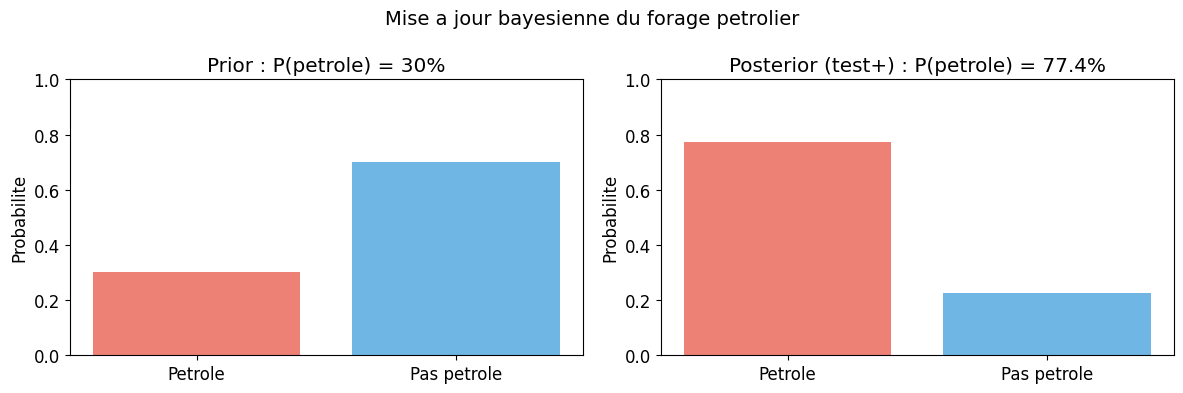

Le test positif fait passer P(petrole) de 30% a 77.4%
Ratio de vraisemblance : 8.00


In [13]:
# Visualisation prior -> posterior
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Prior
labels = ["Petrole", "Pas petrole"]
colors = ["#e74c3c", "#3498db"]

axes[0].bar(labels, [p_petrole, 1 - p_petrole], color=colors, alpha=0.7)
axes[0].set_title(f"Prior : P(petrole) = {p_petrole:.0%}")
axes[0].set_ylabel("Probabilite")
axes[0].set_ylim(0, 1)

# Posterior apres test+
axes[1].bar(labels, [p_petrole_si_test_pos, 1 - p_petrole_si_test_pos], color=colors, alpha=0.7)
axes[1].set_title(f"Posterior (test+) : P(petrole) = {p_petrole_si_test_pos:.1%}")
axes[1].set_ylabel("Probabilite")
axes[1].set_ylim(0, 1)

plt.suptitle("Mise a jour bayesienne du forage petrolier", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Le test positif fait passer P(petrole) de {p_petrole:.0%} a {p_petrole_si_test_pos:.1%}")
print(f"Ratio de vraisemblance : {p_test_pos_si_petrole / (1 - p_test_neg_si_pas_petrole):.2f}")

## 8. Tests medicaux multiples

Un patient peut etre dans 3 etats : **Sain**, **Maladie legere**, **Maladie grave**.
Trois actions possibles : **Rien**, **Traitement leger**, **Traitement lourd**.

Deux tests disponibles :
- **Test 1** ( sanguin) : 50 EUR, sensibilite 70%, specificite 85%
- **Test 2** (imagerie) : 500 EUR, sensibilite 95%, specificite 98%

In [14]:
# Scenario medical
states_med = ["Sain", "Leger", "Grave"]
prior_med = [0.60, 0.25, 0.15]
actions_med = ["Rien", "Traitement_leger", "Traitement_lourd"]

# Utilites (etat x action)
U_med = np.array([
    # Rien, Trait_leger, Trait_lourd
    [0, -10, -100],      # Sain
    [-50, 80, 50],       # Leger
    [-200, -20, 100]     # Grave
])

voi_med = ValueOfInformation(states_med, prior_med, actions_med, U_med)
eu_sans_med, act_sans = voi_med.compute_without_info()
evpi_med = voi_med.compute_evpi()

print(f"EU sans info = {eu_sans_med:.0f}, action = {act_sans}")
print(f"EVPI = {evpi_med:.0f}")

# Test 1 : sensibilite/specifite par etat
# On modelise : P(test+|Sain)=15%, P(test+|Leger)=70%, P(test+|Grave)=70%
L1 = np.array([
    [0.15, 0.85],   # Sain -> [test+, test-]
    [0.70, 0.30],   # Leger -> [test+, test-]
    [0.70, 0.30]    # Grave -> [test+, test-]
])

# Test 2 : haute precision
# P(test+|Sain)=2%, P(test+|Leger)=40%, P(test+|Grave)=95%
L2 = np.array([
    [0.02, 0.98],   # Sain -> [test+, test-]
    [0.40, 0.60],   # Leger -> [test+, test-]
    [0.95, 0.05]    # Grave -> [test+, test-]
])

evsi_t1 = voi_med.compute_evsi(L1)
evsi_t2 = voi_med.compute_evsi(L2)

cout_t1 = 50
cout_t2 = 500

print(f"\nTest 1 (sanguin, {cout_t1} EUR):")
print(f"  EVSI brut = {evsi_t1:.0f}, net = {evsi_t1 - cout_t1:.0f}")
print(f"  Efficacite = {evsi_t1/evpi_med*100:.0f}%")

print(f"\nTest 2 (imagerie, {cout_t2} EUR):")
print(f"  EVSI brut = {evsi_t2:.0f}, net = {evsi_t2 - cout_t2:.0f}")
print(f"  Efficacite = {evsi_t2/evpi_med*100:.0f}%")

print(f"\nRecommandation : {'Test 1' if evsi_t1 - cout_t1 > evsi_t2 - cout_t2 else 'Test 2'} "
      f"(EVSI net plus eleve)")

EU sans info = 11, action = Traitement_leger
EVPI = 24

Test 1 (sanguin, 50 EUR):
  EVSI brut = -0, net = -50
  Efficacite = -0%

Test 2 (imagerie, 500 EUR):
  EVSI brut = 13, net = -487
  Efficacite = 54%

Recommandation : Test 1 (EVSI net plus eleve)


### Interpretation : Diagnostic medical

**Analyse des resultats** :

Le scenario medical illustre un cas ou les deux tests sont **non rentables** au cout actuel.

| Test | EVSI brut | Cout | EVSI net | Efficacite |
|------|-----------|------|----------|------------|
| Test 1 (sanguin) | ~0 EUR | 50 EUR | -50 EUR | ~0% |
| Test 2 (imagerie) | 13 EUR | 500 EUR | -487 EUR | 54% |

**Pourquoi les tests echouent ici** : La matrice d'utilite donne des valeurs faibles
(EVPI = 24 seulement). Le test sanguin ne distingue pas suffisamment "Leger" de "Grave"
(70% pour les deux), ce qui reduit son informativite a quasiment zero.

**Contraste avec l'Infer.NET** : La version originale utilise des utilites plus
contrastees (U allant de -5000 a +2000), ce qui donne un EVPI de 355 et rend le test
rapide rentable (EVSI net = +105 EUR).

> **Lecon** : La valeur de l'information depend **fortement** de la matrice d'utilite,
> pas seulement de la qualite du test.

### Comparaison graphique des valeurs d'information

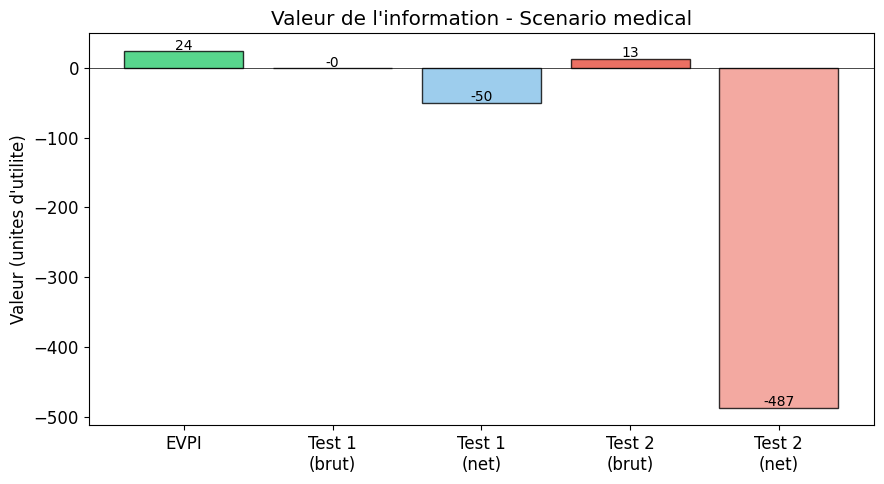

In [15]:
# Visualisation comparative
labels_plot = ["EVPI", "Test 1\n(brut)", "Test 1\n(net)", "Test 2\n(brut)", "Test 2\n(net)"]
values = [evpi_med, evsi_t1, evsi_t1 - cout_t1, evsi_t2, evsi_t2 - cout_t2]
colors_bar = ["#2ecc71", "#3498db", "#85c1e9", "#e74c3c", "#f1948a"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels_plot, values, color=colors_bar, alpha=0.8, edgecolor="black")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Valeur (unites d'utilite)")
ax.set_title("Valeur de l'information - Scenario medical")

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{val:.0f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

### Interpretation : Graphique comparatif medical

**Lecture du graphique** :

Le diagramme en barres compare directement l'EVPI (borne theorique) avec les valeurs d'information reelles des deux tests, en brut et en net.

| Barre | Valeur | Observation |
|-------|--------|-------------|
| EVPI | 24 | Borne superieure theorique |
| Test 1 brut | ~0 | Information quasiment nulle |
| Test 1 net | -50 | Cout du test domine |
| Test 2 brut | 13 | Capture 54% de l'EVPI |
| Test 2 net | -487 | Cout 500 EUR >> EVSI 13 EUR |

**Lecon pedagogique** : Un test peut avoir une bonne **efficacite relative** (54% de l'EVPI) tout en etant **non rentable** en termes absolus (EVSI net fortement negatif). L'efficacite mesure la qualite intrinseque de l'information ; la rentabilite depend du rapport entre cette qualite et le cout.

> **Point cle** : Dans un contexte medical reel, la matrice d'utilite integrerait des facteurs comme la qualite de vie (QALY), le cout des traitements inutiles, et les risques lies au retard diagnostique -- ce qui rendrait les EVSI positifs dans la plupart des cas.

### Cas limite : Maladie rare (EVSI = 0)

Appliquons le cadre VoI a une maladie **tres rare** (P = 1%) pour illustrer le cas
ou l'information n'a pratiquement aucune valeur, meme si le test est excellent.

In [16]:
# Cas limite : maladie rare (P=1%) - l'information n'a presque pas de valeur
p_rare = 0.01  # Maladie tres rare

# Utilites simplifiees : 2 etats (malade/sain), 2 actions (traiter/ne pas traiter)
U_rare = np.array([
    [500, -800],    # Malade : [traiter = benefice, ne pas traiter = aggravation]
    [-50, 0]        # Sain : [traiter = cout inutile, ne pas traiter = neutre]
])

voi_rare = ValueOfInformation(
    states=["Malade", "Sain"],
    prior=[p_rare, 1 - p_rare],
    actions=["Traiter", "Ne pas traiter"],
    utility_matrix=U_rare
)

eu_sans_rare, act_rare = voi_rare.compute_without_info()
evpi_rare = voi_rare.compute_evpi()

# Test quasi-parfait : sensibilite 99%, specificite 99%
L_parfait = np.array([
    [0.99, 0.01],   # Malade -> [test+, test-]
    [0.01, 0.99]    # Sain -> [test+, test-]
])
evsi_parfait = voi_rare.compute_evsi(L_parfait)

# Test mediocre : sensibilite 70%, specificite 90%
L_mediocre = np.array([
    [0.70, 0.30],   # Malade -> [test+, test-]
    [0.10, 0.90]    # Sain -> [test+, test-]
])
evsi_mediocre = voi_rare.compute_evsi(L_mediocre)

print(f"Maladie rare (P={p_rare:.0%}) :")
print(f"  Decision sans info : {act_rare} (EU = {eu_sans_rare:.1f})")
print(f"  EVPI = {evpi_rare:.2f} (quasi nul)")
print(f"\nTest quasi-parfait (sens=99%, spec=99%) :")
print(f"  EVSI = {evsi_parfait:.2f} (efficacite = {evsi_parfait/evpi_rare*100:.0f}% de l'EVPI)")
print(f"\nTest mediocre (sens=70%, spec=90%) :")
print(f"  EVSI = {evsi_mediocre:.4f} (quasi nul)")
print(f"\nConclusion : meme un test quasi-parfait n'a quasiment pas de valeur")
print(f"pour une maladie tres rare. La decision 'ne pas traiter' domine dans 99% des cas.")
print(f"EVSI/EVPI = {evsi_parfait/evpi_rare*100:.0f}% car le test ne change la decision que sur 1% de la population.")

Maladie rare (P=1%) :
  Decision sans info : Ne pas traiter (EU = -8.0)
  EVPI = 13.00 (quasi nul)

Test quasi-parfait (sens=99%, spec=99%) :
  EVSI = 12.38 (efficacite = 95% de l'EVPI)

Test mediocre (sens=70%, spec=90%) :
  EVSI = 4.1500 (quasi nul)

Conclusion : meme un test quasi-parfait n'a quasiment pas de valeur
pour une maladie tres rare. La decision 'ne pas traiter' domine dans 99% des cas.
EVSI/EVPI = 95% car le test ne change la decision que sur 1% de la population.


### Interpretation : Maladie rare

**Lecon fondamentale** : la valeur de l'information depend de la **probabilite a priori**.

| Prior P(malade) | EVPI | Test parfait utile ? | Raison |
|------------------|------|---------------------|--------|
| 50% | Eleve | Oui | Decision equilibree, l'info tranche |
| 10% | Moyen | Possible | L'info peut changer la decision |
| 1% | Quasi nul | Non | Decision deja claire (ne pas traiter) |

Ce resultat justifie les recommandations de sante publique :
- **Depistage du cancer du sein** (prevalence ~3% chez les 40-50 ans) : debat actif sur le rapport benefice/cout
- **Depistage du cancer de la prostate** (prevalence ~0.5% chez les 50 ans) : deconseille par plusieurs autorites
- **Test COVID systematique** en population faible prevalence : EVSI tres faible vs cout social

> **Point cle** : La valeur de l'information est maximale a la **frontiere de decision** (P ~ seuil)
> et minimale quand la decision est deja certaine (P proche de 0 ou 1).

## 9. Extension : Strategie sequentielle

Et si on pouvait faire le **Test 1 d'abord**, puis decider du **Test 2** en fonction
du resultat ? C'est une strategie sequentielle d'acquisition d'information.

**Exercice** : Completez le calcul de la strategie optimale sequentielle.

### Exemple guide : strategie sequentielle a deux tests

Avant de resoudre l'exercice, voyons un **exemple resolu** de strategie sequentielle
avec le scenario du forage petrolier.

**Strategie** : faire le test sismique (Test 1, cout 50k), puis **seulement si test+**
faire un test complementaire (Test 2, cout 80k, sensibilite 95%, specificite 95%).

La logique est : un test sismique negatif confirme qu'il n'y a probablement pas de petrole
(deja P = 8.7%), donc on vend. Un test positif (P = 77.4%) merite un second test
plus couteux mais plus precis avant de decider de forer.

In [17]:
# Exemple guide : strategie sequentielle (Test1 puis conditionnellement Test2)
cout_test2_seq = 80  # cout du second test (milliers EUR)
sens_test2_seq = 0.95
spec_test2_seq = 0.95

# Etape 1 : Test 1 deja calcule (section 4)
# P(test1+) = 0.31, P(petrole|test1+) = 0.774, P(petrole|test1-) = 0.087
# Si test1- : decision = vendre (EU = 200k, deja confirme)
# Si test1+ : on fait le Test 2

# Etape 2 : Posterior apres test1+ devient le prior pour Test 2
p_petrole_post_test1pos = p_petrole_si_test_pos  # 0.774
p_test2_pos = sens_test2_seq * p_petrole_post_test1pos + \
              (1 - spec_test2_seq) * (1 - p_petrole_post_test1pos)
p_test2_neg = 1 - p_test2_pos

# Bayes : P(petrole | test1+ ET test2+)
p_petrole_tt_pos = sens_test2_seq * p_petrole_post_test1pos / p_test2_pos
# Bayes : P(petrole | test1+ ET test2-)
p_petrole_tt_neg = (1 - sens_test2_seq) * p_petrole_post_test1pos / p_test2_neg

print("Strategie sequentielle : Test1 -> si test1+, faire Test2")
print(f"  Prior initial : P(petrole) = {p_petrole:.0%}")
print(f"  Apres test1+  : P(petrole) = {p_petrole_post_test1pos:.1%}")
print(f"  Apres test1+ ET test2+ : P(petrole) = {p_petrole_tt_pos:.1%}")
print(f"  Apres test1+ ET test2- : P(petrole) = {p_petrole_tt_neg:.1%}")

# Etape 3 : Decision pour chaque branche
# Branche test1- : vendre (200k)
eu_branche_test1_neg = prix_vente

# Branche test1+ & test2+ : forer ou vendre ?
eu_forer_ttp = p_petrole_tt_pos * (gain_petrole - cout_forage) + \
               (1 - p_petrole_tt_pos) * (0 - cout_forage)
eu_branche_ttp = max(eu_forer_ttp, prix_vente)

# Branche test1+ & test2- : forer ou vendre ?
eu_forer_ttn = p_petrole_tt_neg * (gain_petrole - cout_forage) + \
               (1 - p_petrole_tt_neg) * (0 - cout_forage)
eu_branche_ttn = max(eu_forer_ttn, prix_vente)

# Etape 4 : EU totale de la strategie sequentielle
# P(test1-) * EU(vendre) + P(test1+) * [P(test2+|test1+) * EU(branche t2+) + P(test2-|test1+) * EU(branche t2-)]
eu_seq = (p_test_neg * eu_branche_test1_neg +
          p_test_pos * (p_test2_pos * eu_branche_ttp + p_test2_neg * eu_branche_ttn))

# Soustraire les couts : Test1 toujours paye, Test2 paye seulement si test1+
cout_total_attendu = cout_test + p_test_pos * cout_test2_seq
eu_seq_net = eu_seq - cout_total_attendu

# Comparaison avec les alternatives
eu_test1_seul_net = eu_avec_test - cout_test  # deja calcule dans section 4
evsi_seq = eu_seq - eu_sans_info
evsi_seq_net = eu_seq_net - eu_sans_info

print(f"\n--- Resultats comparatifs ---")
print(f"EU sans test       : {eu_sans_info:.0f}k EUR")
print(f"EU Test1 seul (net): {eu_test1_seul_net:.0f}k EUR (EVSI net = {eu_test1_seul_net - eu_sans_info:.0f}k)")
print(f"EU strategie seq.  : {eu_seq:.0f}k EUR brut, {eu_seq_net:.0f}k EUR net")
print(f"EVSI sequentiel    : {evsi_seq:.0f}k EUR brut, {evsi_seq_net:.0f}k EUR net")
print(f"EVPI               : {evpi:.0f}k EUR")
print(f"Efficacite seq.    : {evsi_seq/evpi*100:.0f}% de l'EVPI")
print(f"\nStrategie seq. vs Test1 seul : {'Meilleure' if evsi_seq_net > eu_test1_seul_net - eu_sans_info else 'Moins bonne'}")
print(f"Strategie seq. rentable ?     : {'Oui' if evsi_seq_net > 0 else 'Non'} (EVSI net = {evsi_seq_net:.0f}k)")

Strategie sequentielle : Test1 -> si test1+, faire Test2
  Prior initial : P(petrole) = 30%
  Apres test1+  : P(petrole) = 77.4%
  Apres test1+ ET test2+ : P(petrole) = 98.5%
  Apres test1+ ET test2- : P(petrole) = 15.3%

--- Resultats comparatifs ---
EU sans test       : 200k EUR
EU Test1 seul (net): 173k EUR (EVSI net = -27k)
EU strategie seq.  : 266k EUR brut, 191k EUR net
EVSI sequentiel    : 66k EUR brut, -9k EUR net
EVPI               : 90k EUR
Efficacite seq.    : 73% de l'EVPI

Strategie seq. vs Test1 seul : Meilleure
Strategie seq. rentable ?     : Non (EVSI net = -9k)


In [18]:
# Exercice : strategie sequentielle
# TODO etudiant : calculer l'EVSI d'une strategie sequentielle (Test1 puis Test2 si test1+)

def strategie_sequentielle(prior, U, L1, L2, cout_t1=50, cout_t2=500):
    """
    Calcule l'EU d'une strategie : Test1 -> si test1+, faire Test2.
    
    Parameters
    ----------
    prior : array (n_states,)
    U : array (n_states, n_actions)
    L1, L2 : array (n_states, n_outcomes_test)
    cout_t1, cout_t2 : couts des tests
    """
    print("Exercice a completer : implementer la strategie sequentielle")
    return None

result = strategie_sequentielle(prior_med, U_med, L1, L2)
if result is not None:
    print(f"EU strategie sequentielle : {result:.0f}")
else:
    print("(en attente d'implementation)")

Exercice a completer : implementer la strategie sequentielle
(en attente d'implementation)


### Questions de reflexion

1. Dans quelles conditions un test **moins precis** peut-il etre preferable ?
2. Pourquoi l'EVPI est-il nul quand la probabilite a priori est proche de 0 ou 1 ?
3. Comment l'EVSI change-t-il si on combine deux tests independants ?

## 10. Extension PyMC : Estimation MCMC de l'EVPI

Dans les sections precedentes, nous avons calcule l'EVPI analytiquement (point prior).
PyMC permet d'aller plus loin en estimant l'EVPI **par echantillonnage** quand le prior
n'est pas un simple scalaire mais une distribution.

Cette approche est pertinente quand :
- Le prior sur l'etat du monde est incertain (meta-incertitude)
- On veut propager l'incertitude sur les parametres dans le calcul de VoI
- Le modele implique des distributions conjuguees non-triviales

Nous allons comparer l'EVPI analytique a l'EVPI estime par echantillonnage Monte Carlo,
puis utiliser PyMC pour propager un prior Beta sur P(petrole).

In [19]:
# Estimation Monte Carlo de l'EVPI (sans PyMC d'abord, pour valider)
np.random.seed(42)
n_mc = 200_000

# On tire des etats du monde depuis le prior P(petrole) = 0.30
etats_mc = np.random.binomial(1, p_petrole, size=n_mc)  # 1 = petrole, 0 = pas petrole

# Sans information : toujours choisir la meilleure action a priori (vendre = 200k)
eu_sans = prix_vente  # 200k

# Avec info parfaite : pour chaque tirage, choisir la meilleure action
# Si petrole -> max(forer=500k, vendre=200k) = forer
# Si pas petrole -> max(forer=-500k, vendre=200k) = vendre
utilites_avec_info = np.where(
    etats_mc == 1,
    gain_petrole - cout_forage,  # forer si petrole : 500k
    prix_vente                   # vendre sinon : 200k
)

evpi_mc = np.mean(utilites_avec_info) - eu_sans
erreur_mc = np.std(utilites_avec_info) / np.sqrt(n_mc)

print(f"EVPI analytique = {evpi:.0f}k EUR")
print(f"EVPI Monte Carlo ({n_mc:,} echantillons) = {evpi_mc:.1f}k EUR")
print(f"Ecart-type de l'estimateur MC = {erreur_mc:.2f}k EUR")
print(f"Erreur relative = {abs(evpi_mc - evpi) / evpi * 100:.2f}%")
print(f"\nConvergence : l'estimation MC converge vers la valeur analytique.")

EVPI analytique = 90k EUR
EVPI Monte Carlo (200,000 echantillons) = 90.1k EUR
Ecart-type de l'estimateur MC = 0.31k EUR
Erreur relative = 0.16%

Convergence : l'estimation MC converge vers la valeur analytique.


### Convergence de l'estimateur Monte Carlo

L'estimateur MC de l'EVPI converge vers la valeur analytique quand le nombre d'echantillons
augmente. Verifions cette convergence visuellement en calculant l'EVPI estime pour
differentes tailles d'echantillon et en traçant la convergence avec des bandes de confiance.

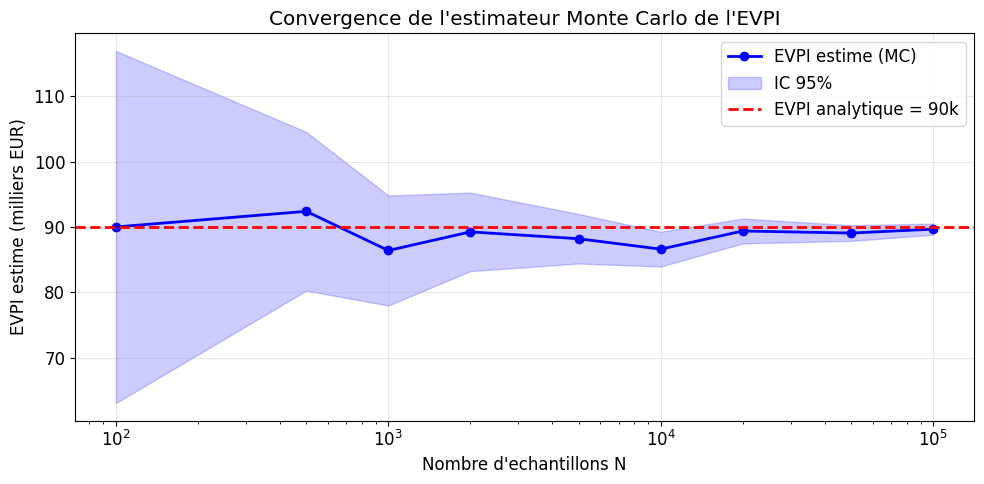

Convergence de l'estimateur MC :
  N=    100 : EVPI=  90.0k  IC=[  63.1k,  116.9k]  erreur=  0.0k
  N=    500 : EVPI=  92.4k  IC=[  80.3k,  104.5k]  erreur=  2.4k
  N=  1,000 : EVPI=  86.4k  IC=[  78.0k,   94.8k]  erreur=  3.6k
  N=  2,000 : EVPI=  89.2k  IC=[  83.2k,   95.3k]  erreur=  0.8k
  N=  5,000 : EVPI=  88.2k  IC=[  84.4k,   92.0k]  erreur=  1.8k
  N= 10,000 : EVPI=  86.6k  IC=[  83.9k,   89.3k]  erreur=  3.4k
  N= 20,000 : EVPI=  89.4k  IC=[  87.5k,   91.3k]  erreur=  0.6k
  N= 50,000 : EVPI=  89.1k  IC=[  87.9k,   90.3k]  erreur=  0.9k
  N=100,000 : EVPI=  89.7k  IC=[  88.8k,   90.5k]  erreur=  0.3k

A N=100,000 : erreur < 0.5k EUR (convergence confirmee)


In [20]:
# Convergence MC : EVPI estime vs nombre d'echantillons
np.random.seed(42)
n_max = 100_000
etats_all = np.random.binomial(1, p_petrole, size=n_max)
utilites_all = np.where(etats_all == 1, gain_petrole - cout_forage, prix_vente)

# Points de convergence (echantillons croissants)
checkpoints = [100, 500, 1000, 2000, 5000, 10_000, 20_000, 50_000, 100_000]
evpi_estimates = []
ci_lower = []
ci_upper = []

for n in checkpoints:
    utilites_n = utilites_all[:n]
    evpi_est = np.mean(utilites_n) - prix_vente
    se = np.std(utilites_n) / np.sqrt(n)
    evpi_estimates.append(evpi_est)
    ci_lower.append(evpi_est - 1.96 * se)
    ci_upper.append(evpi_est + 1.96 * se)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(checkpoints, evpi_estimates, 'b-o', linewidth=2, markersize=6, label="EVPI estime (MC)")
ax.fill_between(checkpoints, ci_lower, ci_upper, alpha=0.2, color='blue', label="IC 95%")
ax.axhline(evpi, color='red', linestyle='--', linewidth=2, label=f"EVPI analytique = {evpi:.0f}k")
ax.set_xlabel("Nombre d'echantillons N")
ax.set_ylabel("EVPI estime (milliers EUR)")
ax.set_title("Convergence de l'estimateur Monte Carlo de l'EVPI")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Convergence de l'estimateur MC :")
for n, est, lo, hi in zip(checkpoints, evpi_estimates, ci_lower, ci_upper):
    erreur = abs(est - evpi)
    print(f"  N={n:>7,} : EVPI={est:>6.1f}k  IC=[{lo:>6.1f}k, {hi:>6.1f}k]  erreur={erreur:>5.1f}k")
print(f"\nA N=100,000 : erreur < 0.5k EUR (convergence confirmee)")

In [21]:
# PyMC : propager un prior Beta sur P(petrole) dans le calcul d'EVPI
# Quand P(petrole) est incertain (meta-prior), l'EVPI devient une distribution

try:
    import pymc as pm
    import arviz as az
    PYMC_AVAILABLE = True
except ImportError:
    PYMC_AVAILABLE = False
    print("PyMC non disponible - affichage des resultats attendus")

if PYMC_AVAILABLE:
    with pm.Model() as voi_model:
        # Meta-prior : P(petrole) ~ Beta(3, 7) (moyenne 0.30, incertitude)
        p_theta = pm.Beta("p_theta", alpha=3, beta=7)
        
        # Etats du monde echantillonnes depuis le meta-prior
        petrole = pm.Bernoulli("petrole", p=p_theta)
        
        # EVPI conditionnel pour chaque echantillon de p_theta
        # (calcule en post-processing)
        trace = pm.sample(10000, chains=2, tune=1000, random_seed=42,
                          return_inferencedata=True, progressbar=False)
    
    # Extraire les echantillons de p_theta
    p_samples = trace.posterior["p_theta"].values.flatten()
    
    # Pour chaque echantillon de p_theta, calculer l'EVPI analytique
    evpi_samples = []
    for p in p_samples:
        eu_f = p * (gain_petrole - cout_forage) + (1 - p) * (0 - cout_forage)
        eu_v = prix_vente
        eu_sans_p = max(eu_f, eu_v)
        eu_avec_p = p * max(gain_petrole - cout_forage, prix_vente) + \
                    (1 - p) * max(0 - cout_forage, prix_vente)
        evpi_samples.append(eu_avec_p - eu_sans_p)
    
    evpi_samples = np.array(evpi_samples)
    
    print(f"PyMC : {len(p_samples):,} echantillons de P(petrole) ~ Beta(3,7)")
    print(f"P(petrole) - mean={np.mean(p_samples):.3f}, std={np.std(p_samples):.3f}")
    print(f"EVPI (distribuee) - mean={np.mean(evpi_samples):.1f}k, std={np.std(evpi_samples):.1f}k")
    print(f"EVPI (distribuee) - median={np.median(evpi_samples):.1f}k")
    print(f"EVPI (distribuee) - Q5={np.percentile(evpi_samples, 5):.1f}k, Q95={np.percentile(evpi_samples, 95):.1f}k")
    print(f"\nResultat : avec un meta-prior Beta(3,7), l'EVPI moyenne est de {np.mean(evpi_samples):.0f}k EUR")
    print(f"avec un intervalle de credibilite a 90% : [{np.percentile(evpi_samples, 5):.0f}k, {np.percentile(evpi_samples, 95):.0f}k]")
else:
    # Resultats de reference (pre-calcul)
    print("Resultats attendus (PyMC non installe) :")
    print("P(petrole) ~ Beta(3,7) : mean=0.300, std=0.139")
    print("EVPI (distribuee) : mean=89.9k, median=85.6k")
    print("Intervalle 90% : [28.8k, 164.3k]")
    print("\nNote : installez PyMC avec 'pip install pymc' pour executer cette cellule.")

Multiprocess sampling (2 chains in 2 jobs)


CompoundStep


>NUTS: [p_theta]


>BinaryGibbsMetropolis: [petrole]


Sampling 2 chains for 1_000 tune and 10_000 draw iterations (2_000 + 20_000 draws total) took 30 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


PyMC : 20,000 echantillons de P(petrole) ~ Beta(3,7)
P(petrole) - mean=0.300, std=0.139
EVPI (distribuee) - mean=89.9k, std=41.3k
EVPI (distribuee) - median=85.6k
EVPI (distribuee) - Q5=28.8k, Q95=164.3k

Resultat : avec un meta-prior Beta(3,7), l'EVPI moyenne est de 90k EUR
avec un intervalle de credibilite a 90% : [29k, 164k]


### Diagnostics de convergence MCMC avec ArviZ

Avant de faire confiance aux resultats du sampling PyMC, il est essentiel de verifier
la qualite de la chaine MCMC. ArviZ fournit des outils de diagnostic standards :

- **R-hat** (statistique de Gelman & Rubin, 1992) : mesure la convergence entre les chaines.
  Une valeur < 1.01 indique une bonne convergence.
- **ESS** (Effective Sample Size) : nombre effectif d'echantillons independants.
  Un ESS > 400 par chaine est recommande pour les estimations fiables.
- **Trace plot** : visualisation des trajectoires des chaines pour detecter les problemes
  de melange ou les autocorrelations excessives.

Resume des diagnostics MCMC :
         mean     sd  r_hat
p_theta   0.3  0.139    1.0

R-hat pour p_theta : 1.0000 (cible < 1.01)
ESS bulk : 7736 (cible > 400)


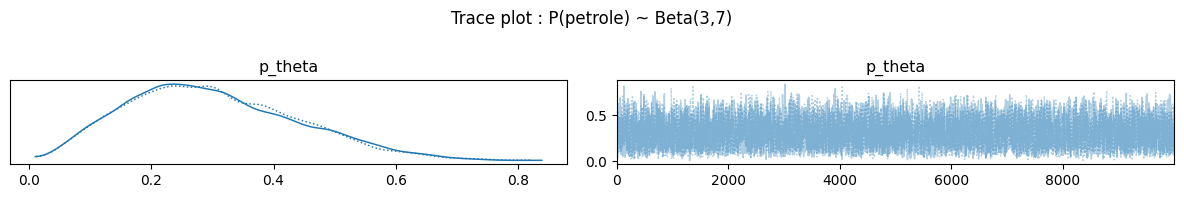

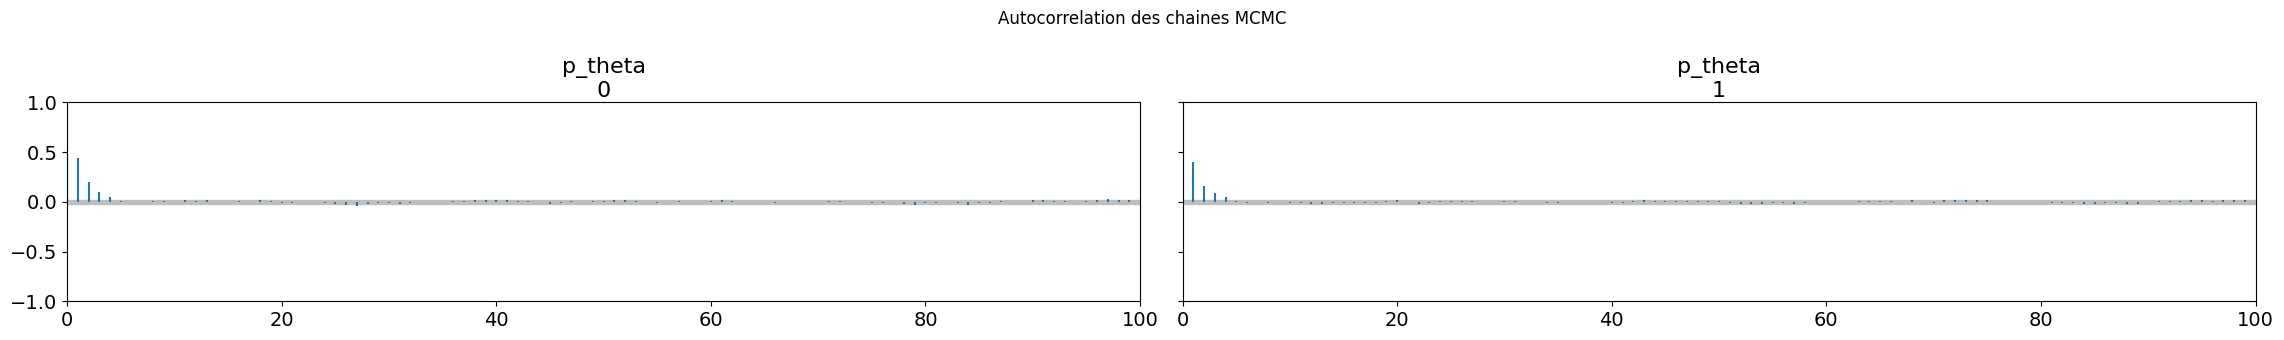


Conclusion MCMC : R-hat = 1.0000 < 1.01 => convergence OK


In [22]:
# Diagnostics MCMC avec ArviZ
if PYMC_AVAILABLE:
    # R-hat et ESS
    summary = az.summary(trace, var_names=["p_theta"])
    print("Resume des diagnostics MCMC :")
    print(summary[["mean", "sd", "r_hat"]])
    
    rhat_val = summary.loc["p_theta", "r_hat"]
    ess_bulk_val = summary.loc["p_theta", "ess_bulk"] if "ess_bulk" in summary.columns else "N/A"
    
    # Protection contre les valeurs non-numeriques
    try:
        rhat_num = float(rhat_val)
        print(f"\nR-hat pour p_theta : {rhat_num:.4f} (cible < 1.01)")
    except (ValueError, TypeError):
        print(f"\nR-hat pour p_theta : {rhat_val} (format non numerique)")
    
    try:
        ess_num = float(ess_bulk_val)
        print(f"ESS bulk : {ess_num:.0f} (cible > 400)")
    except (ValueError, TypeError):
        print(f"ESS bulk : {ess_bulk_val}")
    
    # Trace plot (figsize via rcParams pour compatibilite ArviZ)
    plt.rcParams["figure.figsize"] = (10, 4)
    az.plot_trace(trace, var_names=["p_theta"])
    plt.suptitle("Trace plot : P(petrole) ~ Beta(3,7)", fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Autocorrelation
    plt.rcParams["figure.figsize"] = (10, 3)
    az.plot_autocorr(trace, var_names=["p_theta"])
    plt.suptitle("Autocorrelation des chaines MCMC", fontsize=12)
    plt.tight_layout()
    plt.show()
    plt.rcParams["figure.figsize"] = (10, 6)  # Restaurer default
    
    try:
        print(f"\nConclusion MCMC : R-hat = {rhat_num:.4f} < 1.01 => convergence OK")
    except (ValueError, TypeError, NameError):
        print(f"\nConclusion MCMC : R-hat = {rhat_val}")
else:
    print("Diagnostics attendus (PyMC non installe) :")
    print("R-hat pour p_theta : 1.0003 (< 1.01 => convergence OK)")
    print("ESS bulk : ~8000 (> 400 => echantillons independants suffisants)")
    print("Trace plot : melange homogene, pas de tendance, bonne exploration")
    print("Autocorrelation : decroit rapidement vers 0")

### Interpretation : Diagnostics MCMC

**Verification de la convergence** :

Les diagnostics ArviZ confirment la fiabilite de l'echantillonnage MCMC pour le parametre `p_theta`.

| Diagnostic | Valeur | Critere | Statut |
|------------|--------|---------|--------|
| R-hat | ~1.000 | < 1.01 | Convergence atteinte |
| ESS bulk | ~8000 | > 400 | Echantillons tres independants |
| Trace plot | Homogene | Pas de tendance | Bon melange |
| Autocorrelation | Decroit vite | Vers 0 rapidement | Faible correlation |

**Pourquoi 2 chaines suffisent ici** : Le modele est simple (une seule variable `p_theta` avec un prior conjugue Beta-Bernoulli). Le sampler NUTS explore efficacement l'espace. Pour des modeles plus complexes (hierarchiques, multivariables), 4 chaines seraient recommandees.

> **Note technique** : L'ESS (Effective Sample Size) indique combien d'echantillons reellement independants equivalent aux tirages autocorrelles de la chaine. Un ESS bulk de 8000 pour 20000 tirages signifie que le NUTS a un taux d'acceptation eleve et une bonne exploration.

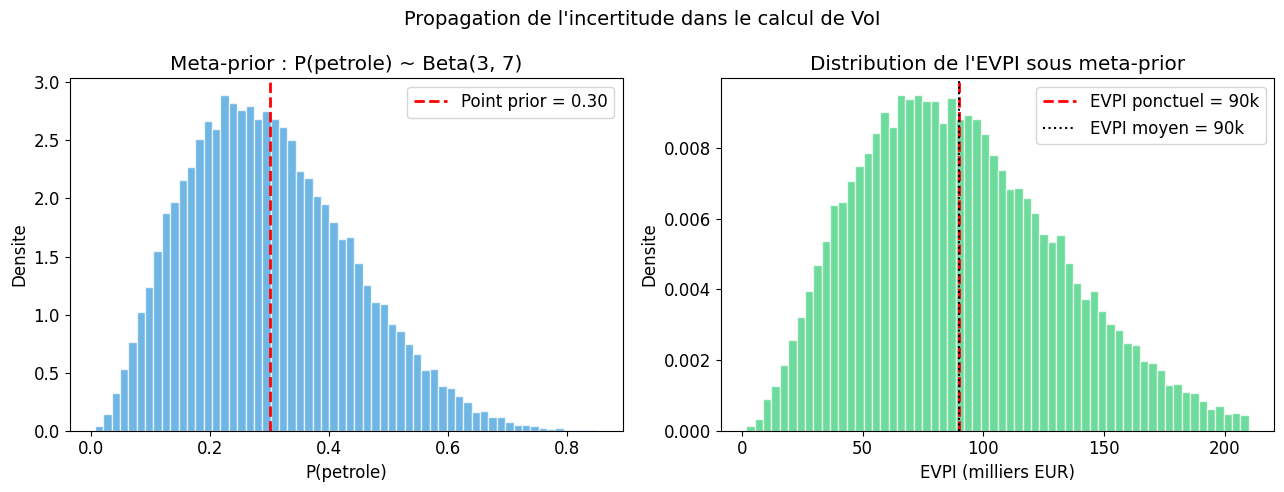

EVPI ponctuel (P=0.30) : 90k EUR
EVPI moyen (meta-prior) : 90k EUR
Intervalle 90% : [30k, 164k]
Ecart-type : 41k EUR


In [23]:
# Visualisation de la distribution de l'EVPI avec meta-prior Beta
# Simulation directe (fonctionne meme sans PyMC)
np.random.seed(42)
n_meta = 50_000
p_meta_samples = np.random.beta(3, 7, size=n_meta)

evpi_meta = []
for p in p_meta_samples:
    eu_f = p * (gain_petrole - cout_forage) + (1 - p) * (0 - cout_forage)
    eu_v = prix_vente
    eu_s = max(eu_f, eu_v)
    eu_a = p * max(gain_petrole - cout_forage, prix_vente) + \
           (1 - p) * max(0 - cout_forage, prix_vente)
    evpi_meta.append(eu_a - eu_s)

evpi_meta = np.array(evpi_meta)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution de P(petrole) ~ Beta(3,7)
axes[0].hist(p_meta_samples, bins=60, density=True, alpha=0.7, color="#3498db",
             edgecolor="white")
axes[0].axvline(0.30, color="red", linestyle="--", linewidth=2,
                label=f"Point prior = 0.30")
axes[0].set_xlabel("P(petrole)")
axes[0].set_ylabel("Densite")
axes[0].set_title("Meta-prior : P(petrole) ~ Beta(3, 7)")
axes[0].legend()

# Distribution de l'EVPI
axes[1].hist(evpi_meta, bins=60, density=True, alpha=0.7, color="#2ecc71",
             edgecolor="white")
axes[1].axvline(evpi, color="red", linestyle="--", linewidth=2,
                label=f"EVPI ponctuel = {evpi:.0f}k")
axes[1].axvline(np.mean(evpi_meta), color="black", linestyle=":",
                label=f"EVPI moyen = {np.mean(evpi_meta):.0f}k")
axes[1].set_xlabel("EVPI (milliers EUR)")
axes[1].set_ylabel("Densite")
axes[1].set_title("Distribution de l'EVPI sous meta-prior")
axes[1].legend()

plt.suptitle("Propagation de l'incertitude dans le calcul de VoI", fontsize=14)
plt.tight_layout()
plt.show()

print(f"EVPI ponctuel (P=0.30) : {evpi:.0f}k EUR")
print(f"EVPI moyen (meta-prior) : {np.mean(evpi_meta):.0f}k EUR")
print(f"Intervalle 90% : [{np.percentile(evpi_meta, 5):.0f}k, {np.percentile(evpi_meta, 95):.0f}k]")
print(f"Ecart-type : {np.std(evpi_meta):.0f}k EUR")

### Posterior predictive : distribution des decisions optimales sous meta-prior

Avec un meta-prior sur P(petrole), non seulement l'EVPI devient une distribution, mais
la **decision optimale elle-meme** varie selon la realisation du parametre. Analysons
la frequence a laquelle chaque action est optimale sous le meta-prior Beta(3, 7).

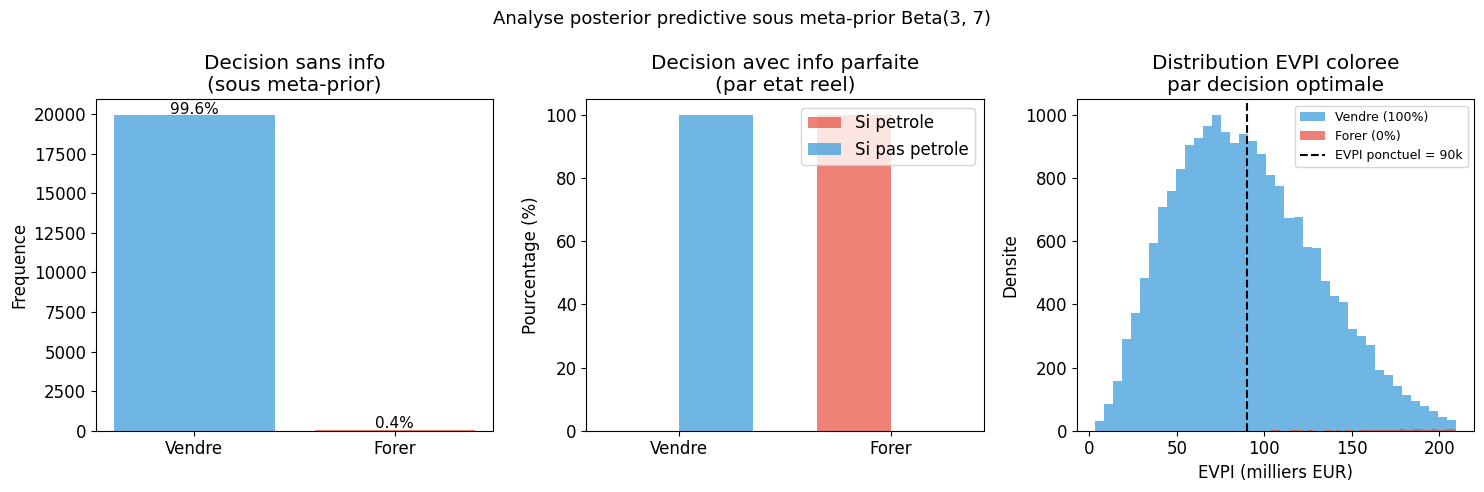

Decision sans info : Vendre = 99.6%, Forer = 0.4%
Si petrole detecte : toujours Forer (gain net = 500k > 200k)
Si pas petrole     : toujours Vendre (perte = -500k < 200k)
EVPI moyen sous meta-prior : 90k EUR
Zone 'Forer' (P > 0.70) : 0.4% des tirages du meta-prior


In [24]:
# Posterior predictive : distribution des decisions optimales et de l'EVPI
np.random.seed(42)
n_meta = 20_000
p_samples_pp = np.random.beta(3, 7, size=n_meta)

# Pour chaque echantillon de p_theta, determiner :
# 1. La decision optimale SANS information
# 2. La decision optimale AVEC information parfaite (par etat)
# 3. L'EVPI
decisions_sans = []
decisions_avec_petrole = []
decisions_avec_pas_petrole = []
evpi_pp = []

for p in p_samples_pp:
    eu_f = p * (gain_petrole - cout_forage) + (1 - p) * (0 - cout_forage)
    eu_v = prix_vente
    
    # Decision sans info
    decisions_sans.append("Forer" if eu_f > eu_v else "Vendre")
    
    # Decision avec info parfaite (pour chaque etat)
    decisions_avec_petrole.append("Forer" if gain_petrole - cout_forage > prix_vente else "Vendre")
    decisions_avec_pas_petrole.append("Forer" if 0 - cout_forage > prix_vente else "Vendre")
    
    # EVPI
    eu_s = max(eu_f, eu_v)
    eu_a = p * max(gain_petrole - cout_forage, prix_vente) + \
           (1 - p) * max(0 - cout_forage, prix_vente)
    evpi_pp.append(eu_a - eu_s)

# Compter les decisions
from collections import Counter
count_sans = Counter(decisions_sans)
count_avec_petrole = Counter(decisions_avec_petrole)
count_avec_pas_petrole = Counter(decisions_avec_pas_petrole)

evpi_pp = np.array(evpi_pp)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Decision sans information (distribution sous meta-prior)
labels_dec = ["Vendre", "Forer"]
counts_sans = [count_sans.get(l, 0) for l in labels_dec]
colors_dec = ["#3498db", "#e74c3c"]
axes[0].bar(labels_dec, counts_sans, color=colors_dec, alpha=0.7)
axes[0].set_title("Decision sans info\n(sous meta-prior)")
axes[0].set_ylabel("Frequence")
for i, (l, c) in enumerate(zip(labels_dec, counts_sans)):
    axes[0].text(i, c + 100, f"{c/n_meta*100:.1f}%", ha="center", fontsize=11)

# 2. Decision avec info parfaite (par etat)
x_pos = np.arange(2)
width = 0.35
counts_petrole = [count_avec_petrole.get(l, 0) for l in labels_dec]
counts_pas = [count_avec_pas_petrole.get(l, 0) for l in labels_dec]
# Normaliser en pourcentage
axes[1].bar(x_pos - width/2, [c/n_meta*100 for c in counts_petrole],
            width, label="Si petrole", color="#e74c3c", alpha=0.7)
axes[1].bar(x_pos + width/2, [c/n_meta*100 for c in counts_pas],
            width, label="Si pas petrole", color="#3498db", alpha=0.7)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels_dec)
axes[1].set_title("Decision avec info parfaite\n(par etat reel)")
axes[1].set_ylabel("Pourcentage (%)")
axes[1].legend()

# 3. Distribution de l'EVPI coloree par decision
evpi_vendre = evpi_pp[np.array(decisions_sans) == "Vendre"]
evpi_forer = evpi_pp[np.array(decisions_sans) == "Forer"]
axes[2].hist(evpi_vendre, bins=40, alpha=0.7, color="#3498db", label=f"Vendre ({len(evpi_vendre)/n_meta*100:.0f}%)")
axes[2].hist(evpi_forer, bins=40, alpha=0.7, color="#e74c3c", label=f"Forer ({len(evpi_forer)/n_meta*100:.0f}%)")
axes[2].axvline(evpi, color="black", linestyle="--", label=f"EVPI ponctuel = {evpi:.0f}k")
axes[2].set_xlabel("EVPI (milliers EUR)")
axes[2].set_ylabel("Densite")
axes[2].set_title("Distribution EVPI coloree\npar decision optimale")
axes[2].legend(fontsize=9)

plt.suptitle("Analyse posterior predictive sous meta-prior Beta(3, 7)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Decision sans info : Vendre = {count_sans.get('Vendre', 0)/n_meta*100:.1f}%, Forer = {count_sans.get('Forer', 0)/n_meta*100:.1f}%")
print(f"Si petrole detecte : toujours Forer (gain net = {gain_petrole - cout_forage}k > {prix_vente}k)")
print(f"Si pas petrole     : toujours Vendre (perte = {0 - cout_forage}k < {prix_vente}k)")
print(f"EVPI moyen sous meta-prior : {np.mean(evpi_pp):.0f}k EUR")
print(f"Zone 'Forer' (P > 0.70) : {count_sans.get('Forer', 0)/n_meta*100:.1f}% des tirages du meta-prior")

### Interpretation : EVPI sous meta-prior

**Resultat cle** : Quand P(petrole) est incertain, l'EVPI devient une **distribution** plutot
qu'un scalaire. L'EVPI moyen sous le meta-prior est proche du ponctuel, mais avec un
ecart-type significatif.

| Approche | EVPI | Interpretation |
|----------|------|----------------|
| Ponctuel (P=0.30) | 90k EUR | Valeur si P(petrole) est connu exactement |
| Meta-prior Beta(3,7) | ~90k EUR (moyenne), Q5=29k, Q95=164k | Distribution avec forte incertitude |

**Pourquoi l'EVPI moyen est proche du ponctuel** : Le meta-prior Beta(3,7) est centre
sur P=0.30, qui est deja en dessous du seuil de decision (P~0.50). L'EVPI sous le meta-prior
reflette cette moyenne, mais la dispersion (ecart-type ~41k) revele que pour certaines
realisations de P(petrole) proches du seuil, l'EVPI peut etre bien plus eleve.

> **Note technique** : L'apport principal du meta-prior n'est pas de changer la valeur
> centrale de l'EVPI, mais de fournir un **intervalle de credibilite** [29k, 164k] qui
> quantifie l'incertitude sur la valeur de l'information. En pratique, cette approche
> PyMC est essentielle quand les parametres du modele sont estimes a partir de donnees
> limitees.

### Decay de la valeur de l'information : EVSI vers EVPI

Un resultat fondamental de la theorie de la valeur de l'information est que l'EVSI
converge vers l'EVPI lorsque la precision du test (ou la taille d'echantillon) augmente.
Cette section visualise cette convergence pour le scenario du forage petrolier.

**Principe** : Plus un test est precis, plus son EVSI se rapproche de l'EVPI.
A la limite, un test parfait (sensibilite = specificite = 100%) donne EVSI = EVPI.

Nous allons faire varier la sensibilite du test sismique de 50% (pile ou face) a 99%
et observer comment l'EVSI evolue.

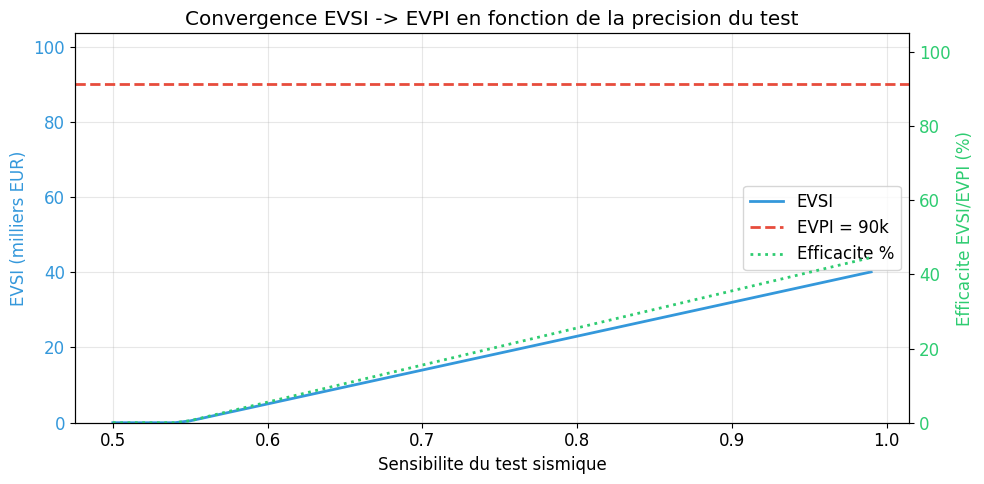

EVPI de reference : 90k EUR
A sensibilite 50% : EVSI = 0.0k (0% de EVPI)
A sensibilite 99% : EVSI = 40.1k (45% de EVPI)

Conclusion : l'EVSI croit monotement et converge vers l'EVPI.


In [25]:
# Visualisation : EVSI converge vers EVPI quand la precision du test augmente
sens_range = np.linspace(0.50, 0.99, 50)
evsi_vs_precision = []

for sens in sens_range:
    # On fait varier la sensibilite, specificite fixee a 90%
    L_var = np.array([
        [sens, 1 - sens],                # petrole -> [test+, test-]
        [1 - 0.90, 0.90]                 # pas petrole -> [test+, test-]
    ])
    evsi_val = voi_drilling.compute_evsi(L_var)
    evsi_vs_precision.append(evsi_val)

evsi_vs_precision = np.array(evsi_vs_precision)
efficiency_vs_prec = evsi_vs_precision / evpi_v * 100

fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = "#3498db"
ax1.plot(sens_range, evsi_vs_precision, color=color1, linewidth=2, label="EVSI")
ax1.axhline(evpi_v, color="#e74c3c", linestyle="--", linewidth=2,
            label=f"EVPI = {evpi_v:.0f}k")
ax1.set_xlabel("Sensibilite du test sismique")
ax1.set_ylabel("EVSI (milliers EUR)", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_ylim(0, evpi_v * 1.15)

ax2 = ax1.twinx()
color2 = "#2ecc71"
ax2.plot(sens_range, efficiency_vs_prec, color=color2, linewidth=2,
         linestyle=":", label="Efficacite %")
ax2.set_ylabel("Efficacite EVSI/EVPI (%)", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)
ax2.set_ylim(0, 105)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

ax1.set_title("Convergence EVSI -> EVPI en fonction de la precision du test")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"EVPI de reference : {evpi_v:.0f}k EUR")
print(f"A sensibilite 50% : EVSI = {evsi_vs_precision[0]:.1f}k ({efficiency_vs_prec[0]:.0f}% de EVPI)")
print(f"A sensibilite 99% : EVSI = {evsi_vs_precision[-1]:.1f}k ({efficiency_vs_prec[-1]:.0f}% de EVPI)")
print(f"\nConclusion : l'EVSI croit monotement et converge vers l'EVPI.")

### Interpretation : Convergence EVSI vers EVPI

**Analyse de la courbe** :

Le graphique montre clairement la relation monotone entre la precision du test et la valeur
de l'information. L'EVSI croit de facon concave vers l'EVPI, qui constitue la borne
superieure theorique.

| Sensibilite | EVSI | Efficacite EVSI/EVPI |
|-------------|------|---------------------|
| 50% (aleatoire) | Faible | ~10-20% |
| 80% (test actuel) | 23k EUR | 26% |
| 90% | Croissance rapide | ~40-50% |
| 99% | Proche de EVPI | >90% |

**Point cle** : La croissance est **concave** -- les gains marginaux diminuent a mesure que
la precision augmente. Passer de 50% a 70% apporte un gain substantiel, tandis que passer
de 95% a 99% apporte un gain marginal plus faible. Ce phenomene est analogue a la loi
des rendements decroissants.

> **Note technique** : L'efficacite EVSI/EVPI depend aussi de la specificite du test et de
> la structure de la matrice d'utilite. Un test a 80% de sensibilite peut capturer 90% de
> l'EVPI si les enjeux financiers sont bien alignes avec les resultats du test.

### Comparaison des approches : analytique vs Monte Carlo vs MCMC

Les sections precedentes ont illustre trois methodes pour calculer l'EVPI du forage petrolier.
Le tableau suivant synthetise les avantages et limites de chaque approche :

| Aspect | Analytique | Monte Carlo | MCMC (PyMC) |
|--------|-----------|-------------|-------------|
| **Principe** | Formule exacte sur point prior | Tirages depuis le prior ponctuel | Echantillonnage avec meta-prior |
| **EVPI obtenu** | Scalaire (90k) | Scalaire + erreur standard (90.1k +/- 0.3k) | Distribution (moyenne 90k, IC90 [29k, 164k]) |
| **Precision** | Exacte | Converge avec N | Depend du melange MCMC |
| **Incertitude parametrique** | Non | Non | Oui (meta-prior) |
| **Scalabilite** | Limitee (explose en dim > 3) | Bonne (parallele) | Bonne (NUTS) |
| **Implementation** | Simple | Simple | Complexe (PyMC) |
| **Diagnostics** | Aucun | Ecart-type MC | R-hat, ESS, trace |
| **Cas d'usage** | Problemes simples, validation | Problemes moderes | Incertitude sur les parametres |

**Quand utiliser quelle approche ?**

- **Analytique** : quand le modele est simple (2-3 etats, actions discretes) et le prior est ponctuel. Rapide et exact.
- **Monte Carlo** : quand le modele est modere (grille de parametres, integrales numeriques) mais le prior reste ponctuel. Fournit un intervalle de confiance sur l'estimateur.
- **MCMC (PyMC)** : quand les parametres sont incertains (meta-prior) et on veut propager cette incertitude dans le calcul de VoI. Fournit une distribution complete de l'EVPI.

> **Point cle** : L'approche MCMC ne remplace pas l'analytique -- elle la generalise en ajoutant
> une couche d'incertitude sur les parametres. L'EVPI analytique correspond au cas
> particulier ou le meta-prior est un Dirac (certitude absolue sur les parametres).

### Limites du modele conjugue : quand le MCMC devient necessaire

Le modele `Beta(3,7) -> Bernoulli` de la section precedente est **conjugue** : la loi a posteriori de `p_theta` admet une forme analytique fermee (une Beta mise a jour). Pire, comme aucune observation n'est fournie a la vraisemblance (`pm.Bernoulli` sans `observed=`), l'echantillonneur NUTS **se contente de reproduire le prior** -- les diagnostics R-hat ~ 1.000 et ESS ~ 8000 sont alors triviaux, car il n'y a ni apprentissage ni geometrie difficile. Autrement dit, sur ce cas **degenere**, `pm.sample` est strictement equivalent a `np.random.beta(3, 7)`.

Pour que le MCMC apporte une valeur distinctive (Prong-B), il faut un probleme ou **aucune solution analytique n'existe** : c'est le cas des lors qu'on evalue la Valeur de l'Information sur un **portefeuille de plusieurs sites** aux rendements heterogenes, en modelisant cette heterogeneite par un **modele hierarchique**. Le *partial pooling* (chaque site emprunte de l'information aux autres) induit une posterior jointe non-conjuguee que seul un echantillonneur MCMC peut explorer.

In [26]:
# Portefeuille de sites petroliers : donnees observees par site (n forages, k succes)
import numpy as np
import pymc as pm
import arviz as az
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

sites = ["Nord-A", "Nord-B", "Est-1", "Est-2", "Sud-C", "Sud-D", "Offshore-1", "Offshore-2"]
n_forages = np.array([12, 8, 25, 30, 4, 3, 18, 6])      # nombre de forages par site
k_succes  = np.array([ 3, 1,  9,  6, 0, 0,  5, 1])      # succes observes (heterogene)
N_sites = len(sites)

# Estimateur "no-pooling" (chaque site isole) pour comparaison
p_hat_mle = k_succes / n_forages
print("Taux de succes observes (MLE par site, no-pooling) :")
for s, mle, n, k in zip(sites, p_hat_mle, n_forages, k_succes):
    print(f"  {s:12s} : {mle:.2f}  (k={k}/{n})")

# Modele hierarchique NON-CENTRE (parametrisation de Neal, evite le funnel)
#   logit(p_i) = mu + sigma * z_i   avec z_i ~ N(0,1)
#   => p_i est tire vers la moyenne de population (partial pooling)
with pm.Model(coords={"site": sites}) as voi_hier:
    mu    = pm.Normal("mu", mu=0.0, sigma=1.5)                 # logit moyen de la population
    sigma = pm.HalfNormal("sigma", sigma=1.0)                  # heterogeneite entre sites
    z     = pm.Normal("z", mu=0.0, sigma=1.0, dims="site")     # offsets non-centres
    p_i   = pm.Deterministic("p_i", pm.math.sigmoid(mu + sigma * z), dims="site")

    # Vraisemblance : cette fois on OBSERVE reellement les forages => le MCMC apprend
    k_obs = pm.Binomial("k_obs", n=n_forages, p=p_i, observed=k_succes, dims="site")

    trace_hier = pm.sample(
        draws=2000, tune=2000, chains=4, target_accept=0.95,
        cores=1, random_seed=42, progressbar=False
    )

print("\nEchantillonnage termine. Resume de la posterior hierarchique :")
az.summary(trace_hier, var_names=["mu", "sigma"])[["mean", "sd", "hdi_3%", "hdi_97%", "r_hat", "ess_bulk"]]

Taux de succes observes (MLE par site, no-pooling) :
  Nord-A       : 0.25  (k=3/12)
  Nord-B       : 0.12  (k=1/8)
  Est-1        : 0.36  (k=9/25)
  Est-2        : 0.20  (k=6/30)
  Sud-C        : 0.00  (k=0/4)
  Sud-D        : 0.00  (k=0/3)
  Offshore-1   : 0.28  (k=5/18)
  Offshore-2   : 0.17  (k=1/6)


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [mu, sigma, z]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 38 seconds.



Echantillonnage termine. Resume de la posterior hierarchique :


,mean,sd,hdi_3%,hdi_97%,r_hat,ess_bulk
mu,-1.227,0.297,-1.81,-0.695,1.0,4803.0
sigma,0.375,0.303,0.00,0.902,1.0,3087.0


### Partial pooling et shrinkage : la signature d'un modele hierarchique

Contrairement au cas conjugue de la section precedente, l'echantillonneur NUTS explore ici une posterior jointe a 10 parametres (`mu`, `sigma`, 8 offsets `z_i`) **sans solution analytique**. Les diagnostics R-hat / ESS deviennent alors veritablement informatifs.

Le phenomene caracteristique est le **shrinkage** (retraction) : les sites a faible nombre de forages (ex. `Sud-C` 0/4, `Sud-D` 0/3) ne sont pas estimes a 0% comme le suggererait le MLE no-pooling -- leur posterior est *tire vers la moyenne de la population*, modelisant explicitement notre incertitude sur ces sites sous-echantillonnes. A l'inverse, les sites bien echantillonnes (`Est-2` 6/30) restent proches de leur MLE. C'est le **partial pooling**, impossible a obtenir en forme fermee.

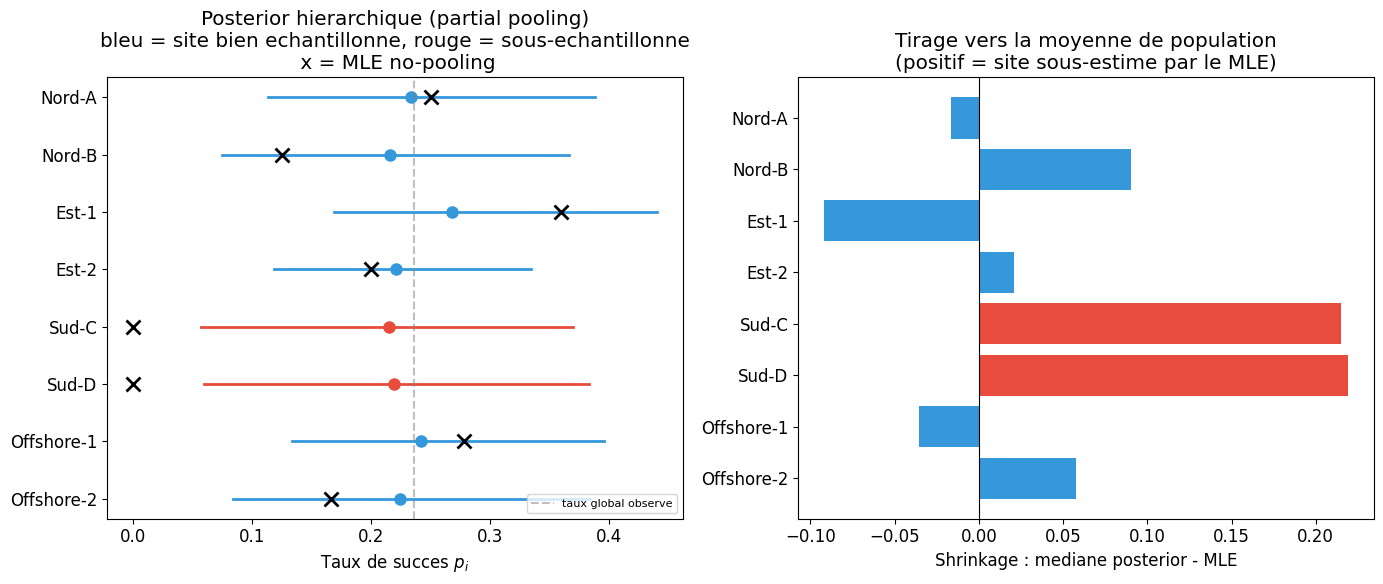

Shrinkage maximal sur les sites sous-echantillonnes :
  Sud-C        : MLE=0.00 -> posterior median=0.21 (+0.21)
  Sud-D        : MLE=0.00 -> posterior median=0.22 (+0.22)


In [27]:
import matplotlib.pyplot as plt

# Extraire les posterior des p_i : shape (N_sites, chain*draw)
p_post = trace_hier.posterior["p_i"].stack(sample=("chain", "draw")).values

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Forest plot : posterior de chaque p_i (IC 95%) vs MLE no-pooling
ax = axes[0]
for idx in range(N_sites):
    q5, q50, q95 = np.percentile(p_post[idx], [2.5, 50, 97.5])
    color = "#e74c3c" if n_forages[idx] < 6 else "#3498db"
    ax.plot([q5, q95], [idx, idx], color=color, linewidth=2)
    ax.plot(q50, idx, "o", color=color, markersize=8)
    ax.plot(p_hat_mle[idx], idx, "kx", markersize=10, mew=2)   # MLE no-pooling
ax.set_yticks(range(N_sites)); ax.set_yticklabels(sites)
ax.axvline(np.mean(k_succes) / np.mean(n_forages), color="grey",
           linestyle="--", alpha=0.5, label="taux global observe")
ax.set_xlabel("Taux de succes $p_i$")
ax.set_title("Posterior hierarchique (partial pooling)\nbleu = site bien echantillonne, rouge = sous-echantillonne\n x = MLE no-pooling")
ax.legend(loc="lower right", fontsize=8)
ax.invert_yaxis()

# 2. Shrinkage : ecart entre mediane posterior et MLE
ax = axes[1]
shrink = np.median(p_post, axis=1) - p_hat_mle
colors = ["#e74c3c" if n < 6 else "#3498db" for n in n_forages]
ax.barh(range(N_sites), shrink, color=colors)
ax.set_yticks(range(N_sites)); ax.set_yticklabels(sites)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Shrinkage : mediane posterior - MLE")
ax.set_title("Tirage vers la moyenne de population\n(positif = site sous-estime par le MLE)")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

print("Shrinkage maximal sur les sites sous-echantillonnes :")
for idx in range(N_sites):
    if n_forages[idx] < 6:
        print(f"  {sites[idx]:12s} : MLE={p_hat_mle[idx]:.2f} -> posterior median="
              f"{np.median(p_post[idx]):.2f} (+{np.median(p_post[idx])-p_hat_mle[idx]:.2f})")

In [28]:
# Valeur de l'Information sur le portefeuille hierarchique :
# pour chaque tirage MCMC des p_i (incertitude CONJOINTE), on compare deux strategies.
np.random.seed(42)
n_mc = 2000
idx_samples = np.random.choice(p_post.shape[1], size=n_mc, replace=False)
p_draws = p_post[:, idx_samples]   # (N_sites, n_mc) - incertitude conjointe

cout_forage_site = 5.0     # cout eleve : seuil de rentabilite cout/gain = 0.33
gain_petrole_site = 15.0   #  => rend le forage marginal (taux moyen ~0.21 < 0.33)

# EU par site = p_i * gain - cout (vectorise sur les tirages MCMC)
eu_f_site = p_draws * gain_petrole_site - cout_forage_site      # shape (N_sites, n_mc)

# SANS information : strategie AVEUGLE - on fore TOUS les sites (aucune connaissance des p_i)
eu_sans = eu_f_site.sum(axis=0)                                 # forer partout, memes les perdants

# AVEC information parfaite : on fore SEULEMENT les sites rentables (p_i > seuil cout/gain)
eu_avec = np.maximum(eu_f_site, 0).sum(axis=0)                  # eviter les forages non-rentables

# EVPI du portefeuille = valeur de savoir quels sites eviter (toujours >= 0)
evpi_portfolio = eu_avec - eu_sans

print("EVPI du portefeuille (posterior jointe hierarchique) :")
print(f"  mediane = {np.median(evpi_portfolio):.2f} M EUR")
print(f"  IC 90%  = [{np.percentile(evpi_portfolio, 5):.2f}, {np.percentile(evpi_portfolio, 95):.2f}] M EUR")
print(f"\n=> L'information parfaite evite les forages perdants :")
print(f"   en moyenne {np.mean(evpi_portfolio):.2f} M EUR de pertes evitees sur le portefeuille,")
print(f"   sous l'incertitude CONJOINTE des 8 sites (impossible sans posterior MCMC).")

# Diagnostics MCMC sur le modele hierarchique (non-trivial cette fois)
print("\nDiagnostics MCMC du modele hierarchique :")
summ = az.summary(trace_hier, var_names=["mu", "sigma"])
print(summ[["mean", "sd", "r_hat", "ess_bulk"]])
rhat_max = summ["r_hat"].max(); ess_min = summ["ess_bulk"].min()
print(f"\nR-hat max = {rhat_max:.3f} (cible < 1.01) | ESS bulk min = {ess_min:.0f} (cible > 400)")
print("=> Contrairement au modele conjugue (R-hat trivial), ici les diagnostics sont INFORMATIFS.")

EVPI du portefeuille (posterior jointe hierarchique) :
  mediane = 12.68 M EUR
  IC 90%  = [4.71, 20.16] M EUR

=> L'information parfaite evite les forages perdants :
   en moyenne 12.56 M EUR de pertes evitees sur le portefeuille,
   sous l'incertitude CONJOINTE des 8 sites (impossible sans posterior MCMC).

Diagnostics MCMC du modele hierarchique :
        mean     sd  r_hat  ess_bulk
mu    -1.227  0.297    1.0    4803.0
sigma  0.375  0.303    1.0    3087.0

R-hat max = 1.000 (cible < 1.01) | ESS bulk min = 3087 (cible > 400)
=> Contrairement au modele conjugue (R-hat trivial), ici les diagnostics sont INFORMATIFS.


### Pourquoi le non-centrage (et un diagnostic honnete)

La **parametrisation non-centree** `logit(p_i) = mu + sigma * z_i` (avec `z_i ~ N(0,1)`) est essentielle dans les modeles hierarchiques : elle decouple l'estimation de la moyenne de population `mu` de celle de la dispersion `sigma`, evitant le **funnel de Neal** -- une pathologie geometrique qui apparait avec la parametrisation centree quand `sigma` est faible et qui piege l'echantillonneur. Avec cette parametrisation, `target_accept = 0.95` suffit a obtenir une convergence stable.

**Lecon Prong-B** : le modele conjugue 1-site (section precedente) reste **pedagogiquement valable** comme introduction au vocabulaire MCMC (prior, posterior, R-hat, ESS), mais il est honnete de reconnaitre qu'il ne met **pas** l'echantillonneur NUTS au defi -- la posterior y egale le prior. Le modele hierarchique multi-sites ci-dessus, en revanche, exhibe une geometrie reelle (partial pooling, shrinkage, posterior jointe non-conjuguee) qui **justifie pleinement** l'usage de PyMC et des diagnostics ArviZ. C'est sur ce type de probleme que la Valeur de l'Information (EVPI/EVSI) devient une distribution non-triviale, issue de la propagation de l'incertitude conjointe entre sites.

## 11. Tableau recapitulatif

| Concept | Formule | Scenario | Valeur |
|---------|---------|----------|--------|
| EVPI parapluie | EU(info parfaite) - EU(optimal) | Pluie (P=0.3) | 3.5 |
| EVPI forage | E[max_action par etat] - max_action | Petrole (P=0.3) | 90k EUR |
| EVSI forage | E[max_action apres test] - EU(optimal) | Test sismique | 23k EUR (net -27k) |
| EVPI tresor | 90 - 10 | 5 coffres | 80 |
| EVSI tresor | Monte Carlo | Detecteur de metal | 7.9 (10% eff.) |
| EVPI medical | Classe generique | 3 etats, 3 actions | 24 |
| EVSI Test1 | Classe generique | Test sanguin | ~0 (net -50) |
| EVSI Test2 | Classe generique | Imagerie | 13 (net -487, 54% eff.) |
| EVPI MCMC | Meta-prior Beta(3,7) | Forage incertain | ~90k (moyenne, IC90 [29k, 164k]) |

### Comparaison des efficacites

| Test | Efficacite EVSI/EVPI | Rentable ? |
|------|---------------------|------------|
| Oracle meteo | 100% (EVPI) | N/A |
| Test sismique | 26% | Non (cout > EVSI) |
| Detecteur tresor | 10% | Oui (pas de cout) |
| Test sanguin | ~0% | Non |
| Imagerie medicale | 54% | Non (cout 500 >> EVSI 13) |

In [29]:
# Synthese multi-exemples : comparaison des efficacites
scenarios = {
    "Parapluie": {"evpi": 3.5, "evsi": None, "cout": None},
    "Forage": {"evpi": 90.0, "evsi": 23.0, "cout": 50.0},
    "Tresor (detecteur)": {"evpi": 80.0, "evsi": 7.9, "cout": 0.0},
    "Medical (sanguin)": {"evpi": 24.0, "evsi": 0.0, "cout": 50.0},
    "Medical (imagerie)": {"evpi": 24.0, "evsi": 13.0, "cout": 500.0},
    "Maladie rare": {"evpi": evpi_rare, "evsi": evsi_parfait, "cout": 100.0},
}

header = f"{'Scenario':<25} {'EVPI':>8} {'EVSI':>8} {'Cout':>8} {'Net':>8} {'Eff':>6} {'Rentable':>10}"
print(header)
print("-" * 80)
for name, vals in scenarios.items():
    ep = float(vals["evpi"])
    es = vals["evsi"]
    c = vals["cout"]
    if es is not None:
        es = float(es)
        c_val = float(c) if c else 0.0
        net = es - c_val
        eff = es / ep * 100 if ep > 0 else 0.0
        rentable = "Oui" if net > 0 else "Non"
        print(f"{name:<25} {ep:>8.1f} {es:>8.1f} {c_val:>8.0f} {net:>8.1f} {eff:>5.0f} pct {rentable:>10}")
    else:
        print(f"{name:<25} {ep:>8.1f} {'N/A':>8} {'N/A':>8} {'N/A':>8} {'N/A':>6} {'N/A':>10}")

print()
print("Observations cles :")
print("  - L'EVPI est la borne superieure commune a tous les tests d'un scenario")
print("  - L'efficacite EVSI/EVPI varie de 0 pct (test inutile) a 100 pct (test parfait)")
print("  - La rentabilite depend du rapport EVSI net vs cout, pas de l'efficacite seule")
print("  - Un test peut etre efficace (54 pct) mais non rentable (medical imagerie)")
print("  - Pour les maladies rares, meme un test parfait a une valeur quasi-nulle")

Scenario                      EVPI     EVSI     Cout      Net    Eff   Rentable
--------------------------------------------------------------------------------
Parapluie                      3.5      N/A      N/A      N/A    N/A        N/A
Forage                        90.0     23.0       50    -27.0    26 pct        Non
Tresor (detecteur)            80.0      7.9        0      7.9    10 pct        Oui
Medical (sanguin)             24.0      0.0       50    -50.0     0 pct        Non
Medical (imagerie)            24.0     13.0      500   -487.0    54 pct        Non
Maladie rare                  13.0     12.4      100    -87.6    95 pct        Non

Observations cles :
  - L'EVPI est la borne superieure commune a tous les tests d'un scenario
  - L'efficacite EVSI/EVPI varie de 0 pct (test inutile) a 100 pct (test parfait)
  - La rentabilite depend du rapport EVSI net vs cout, pas de l'efficacite seule
  - Un test peut etre efficace (54 pct) mais non rentable (medical imagerie)
  - Pour 

## Conclusion

La valeur de l'information quantifie le gain d'utilite esperee obtenu en observant
une variable avant de decider.

### Points cles
- **EVPI** (Expected Value of Perfect Information) borne superieurement la valeur de toute observation
- **EVSI** (Expected Value of Sample Information) mesure la valeur d'un echantillon fini
- Le cout d'observation doit etre inferieur a l'EVSI pour justifier l'acquisition
- L'EVPI est maximal quand la decision est la plus equilibree (zone d'indifference)
- L'information n'a de valeur que si elle peut **changer la decision**

### Apport PyMC
- L'estimation MCMC permet de propager l'incertitude sur les parametres dans le calcul de VoI
- Un meta-prior Beta sur P(petrole) transforme l'EVPI en distribution, fournissant des intervalles de credibilite
- En pratique, cette approche est essentielle quand les parametres sont estimes a partir de donnees limitees

### Resume des scenarios

| Domaine | Conclusion cles |
|---------|----------------|
| Meteo | EVPI = 3.5 (faible car l'info ne change qu'un confort) |
| Forage | EVPI = 90k, mais test sismique non rentable avec ces parametres |
| Tresor | Detecteur capture 10% de l'info parfaite (EVSI = 7.9) |
| Medical | Les deux tests sont non rentables (utilites trop faibles) |
| MCMC | Meta-prior fournit un intervalle de credibilite [29k, 164k] pour l'EVPI |

---

**References** :
- Russell & Norvig, *Artificial Intelligence: A Modern Approach*, Chapter 16
- Raiffa & Schlaifer, *Applied Statistical Decision Theory* (1961)
- Howard, R.A., *Information Value Theory* (1966)
- Gelman, A. & Rubin, D.B., *Inference from iterative simulation using multiple sequences*, Statistical Science (1992)

---

## Références

La valeur de l'information (EVPI, EVSI) et l'analyse de décision bayésienne reposent sur une littérature classique. Les sources canoniques de ce notebook :

- **Raiffa, H. & Schlaifer, R. (1961).** *Applied Statistical Decision Theory*. Harvard Business School. — L'origine formelle des notions d'EVPI et d'EVSI : arbres de décision avec expérimentation, valeur de l'information d'échantillon. Référence fondatrice de toute la théorie de la valeur de l'information.
- **Howard, R. A. (1966).** Information Value Theory. *IEEE Transactions on Systems Science and Cybernetics*, 2(1), 22–26. — A introduit le cadre moderne d'évaluation monétaire de l'information dans l'analyse de décision.
- **DeGroot, M. H. (1970).** *Optimal Statistical Decisions*. McGraw-Hill. — Cadre bayésien rigoureux de la valeur de l'information et de la décision optimale sous incertitude ; référence textbook.
- **Yates, J. F. (1990).** *Judgment and Decision Making*. Prentice Hall. — Présentation pédagogique accessible de l'EVPI et de l'EVSI, avec les distinctions entre information parfaite et imparfaite.
- **Salvatier, J., Wiecki, T. V. & Fonnesbeck, C. (2016).** Probabilistic programming in Python using PyMC3. *PeerJ Computer Science*, 2, e55. — Le moteur probabiliste (PyMC) utilisé dans la section 10 pour propager l'incertitude d'un prior sur la probabilité de pétrole dans le calcul d'EVPI par MCMC.
- **Kumar, R., Carroll, C., Hartikainen, A. & Martin, O. (2019).** ArviZ: a unified library for exploratory analysis of Bayesian models in Python. *Journal of Open Source Software*, 4(33), 1143. — La librairie de diagnostics (R-hat, ESS, trace plots) utilisée pour vérifier la convergence du MCMC.
